### SIT742 - Modern Data Science
### Joshua Bevan
### s224586613

This notebook has been written to satisfy the requirements for Assignment 2 of SIT742. Part 1 will be focusing on data manipulation and pyspark. Part 2 will focus on advanced data science techniques for a particular scenario.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
from wordcloud import WordCloud
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import camelot


from pyspark.sql import SparkSession, functions as F, types as types
from pyspark.sql.window import Window
spark = SparkSession.builder.appName("SIT742-A2").config("spark.ui.showConsoleProgress","false").getOrCreate()

BASE = "/home/josh/code/SIT742 - Modern Data Science/Assignment 2"
REVIEWS_PATH = f"{BASE}/business_review_submission/review.csv"
META_PATH    = f"{BASE}/business_review_submission/meta-review-business.csv"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/20 10:10:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


We establish the technical stack: Spark for distributed processing, pandas/numpy for data manipulation, matplotlib/seaborn for visualisation, sklearn for ML algorithms, statsmodels for time series analysis, nltk for text processing, and camelot for PDF extraction. Some global variables that point to file paths target the review dataset and business metadata that drive the analysis pipeline. BASE can be edited for convenience

Answer 1.1

In [74]:
# set BASE global to dir with business_review_submission folder and ua PDF 
reviews_sdf = spark.read.csv(REVIEWS_PATH, header=True, inferSchema=True, escape='"', multiLine=True)
for c in reviews_sdf.columns: reviews_sdf = reviews_sdf.withColumnRenamed(c, c.strip().lower())

col_text   = "text" if "text" in reviews_sdf.columns else "review_text"
col_time   = "time" if "time" in reviews_sdf.columns else "review_time"
col_gmap   = "gmap_id"
col_user   = "userid" if "userid" in reviews_sdf.columns else ("user_id" if "user_id" in reviews_sdf.columns else "user")
col_rating = "rating" if "rating" in reviews_sdf.columns else "stars"

# drop rows where user or time is null. Note pyspark functions has been imported as F already
reviews_sdf = reviews_sdf.filter(F.col(col_user).isNotNull() & F.col(col_time).isNotNull())

# check text column for null, "none", or where length is 0 or whitespaces; then replace or insert with "no review". Otherwise leave it alone.
reviews_sdf = reviews_sdf.withColumn(
    col_text,
    F.when(F.col(col_text).isNull() | (F.lower(F.col(col_text)) == F.lit("none")) | (F.length(F.trim(F.col(col_text))) == 0), F.lit("no review")).otherwise(F.col(col_text))
)

#prepare timestamp and date columns, time is in milliseconds since epoch
time_as_double = F.col(col_time).cast("double")
timestamp_parsed = F.to_timestamp(F.from_unixtime(time_as_double / 1000))

# add newtime column as date only, defaulted to yyyy-MM-dd 
reviews_sdf = reviews_sdf.withColumn("timestamp_parsed", timestamp_parsed).withColumn("newtime", F.to_date(timestamp_parsed))

# display the first 5 rows 
reviews_sdf.select(col_user, col_gmap, col_time, "timestamp_parsed", "newtime", col_text).show(5, truncate=False)

+---------------------+-------------------------------------+-------------+-------------------+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|user_id              |gmap_id                              |time         |timestamp_parsed   |newtime   |text                                      

Data ingestion with Spark parsing the CSV and special character escaping. Column names are normalised (lowercase, stripped) and mapped to handle schema variations across datasets. We remove rows that are missing  essential fields. We default NULL and white space entries to "no review". Unix timestamps (milliseconds) convert to both full datetime and date-only columns for temporal analysis. The output sample validates preprocessing success.

Answer 1.2

In [3]:
# First, load and prepare the meta data
meta_sdf = spark.read.csv(META_PATH, header=True, inferSchema=True, escape='"', multiLine=True)
for c in meta_sdf.columns: meta_sdf = meta_sdf.withColumnRenamed(c, c.strip().lower())

meta_sdf = meta_sdf.withColumnRenamed("name", "business_name")
name_col = "business_name"
cat_col  = "category" if "category" in meta_sdf.columns else ("categories" if "categories" in meta_sdf.columns else "category")

# saving review count as a double (float) for each gmap_id. I listed gmap_id by review count in descending order for clarity
gmap_counts_sdf = reviews_sdf.groupBy(col_gmap).agg(F.count("*").cast("double").alias("review_count"))
gmap_counts_sdf.orderBy(F.desc("review_count")).show(5, truncate=False)

# join with meta data to get business names
reviews_with_names_sdf = reviews_sdf.join(meta_sdf, on=col_gmap, how="left")

# converting to pandas DF 
df = reviews_with_names_sdf.select(col_user, col_gmap, col_rating, col_text, "newtime", "timestamp_parsed", name_col).toPandas()

# undoing the pyspark time to date handling and converting to pandas datetime
df["timestamp_parsed"] = pd.to_datetime(df["timestamp_parsed"]) - pd.Timedelta(hours=0)
df["newtime"] = pd.to_datetime(df["newtime"])
df["review_time"] = df["timestamp_parsed"].dt.hour.fillna(0).astype(int)
df.head()

+-------------------------------------+------------+
|gmap_id                              |review_count|
+-------------------------------------+------------+
|0x56c897b9ce6000df:0xd707e127588a8c6c|2833.0      |
|0x56c899d058920487:0x12882cc9133f2f54|2594.0      |
|0x56c897c63697ee39:0x419904ababbc740b|2258.0      |
|0x56c8965ee2fb87a1:0x559736347bd48842|2237.0      |
|0x56c89629bde7481f:0x7e8a9413ab25d5d |2219.0      |
+-------------------------------------+------------+
only showing top 5 rows


,user_id,gmap_id,rating,text,newtime,timestamp_parsed,business_name,review_time
0,1.091298e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,We always stay here when in Valdez for silver ...,2019-08-21,2019-08-21 06:12:31,Bear Creek Cabins & RV Park,6
1,1.091298e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,We always stay here when in Valdez for silver ...,2019-08-21,2019-08-21 06:12:31,Bear Creek Cabins & RV Park,6
2,1.132409e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,Great campground for the price. Nice hot unlim...,2017-09-09,2017-09-09 10:46:22,Bear Creek Cabins & RV Park,10
3,1.132409e+20,0x56b646ed2220b77f:0xd8975e316de80952,5,Great campground for the price. Nice hot unlim...,2017-09-09,2017-09-09 10:46:22,Bear Creek Cabins & RV Park,10
4,1.130448e+20,0x56b646ed2220b77f:0xd8975e316de80952,4,We tent camped here for 2 nights while explori...,2016-09-25,2016-09-25 11:11:41,Bear Creek Cabins & RV Park,11


Data ingestion applies the same preprocessing to the review pipeline. We maps "name" to "business_name" and handle category column variants. gmap_id aggregation by reviews is used to show highest volumes. We then do a left join to data-enriches reviews with business context. We use Pandas conversion to do hour-by-hour extraction, timezone normalisation, and clean datetime indexing for downstream analysis.

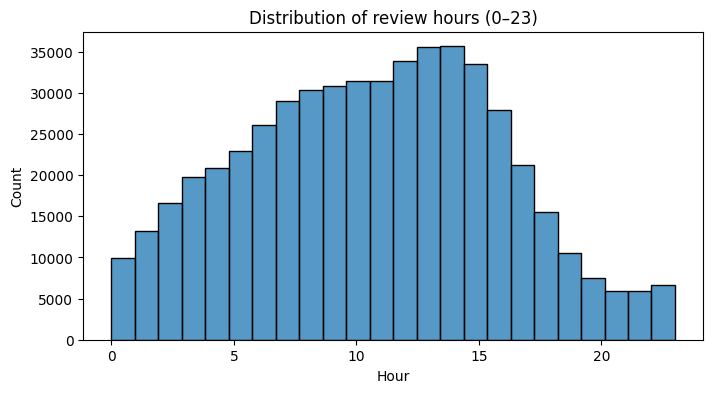

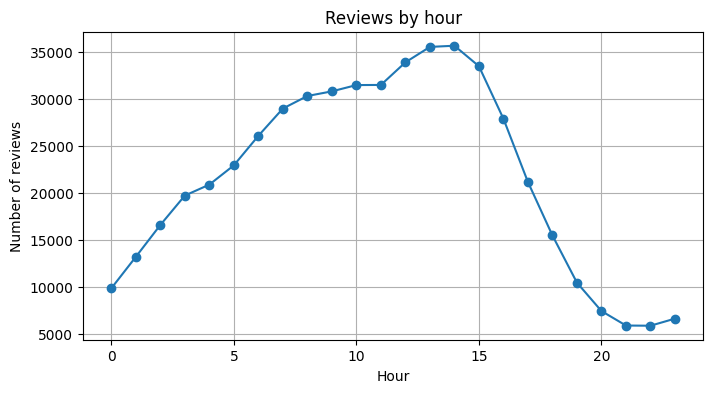

In [4]:
# the most important part of data analytics: visualise visualise visualise
# we are looking at a histogram and line plot of the relationship between review hour and number of reviews between 0000 and 2300 hours
plt.figure(figsize=(8,4))
sns.histplot(df["review_time"], bins=24)
plt.title("Distribution of review hours (0–23)")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
df.groupby("review_time").size().plot(kind="line", marker="o")
plt.title("Reviews by hour")
plt.xlabel("Hour")
plt.ylabel("Number of reviews")
plt.grid(True)
plt.show()


We show some visualisations: histogram shows the hourly distribution density and the line plot shows temporal continuity across a 24-hour cycles. 

We can see that reviews tend to be lodged from 1100 to 1500 hours before sharply dropping. The top quartile of reviews sent is firmly in that midday window and the lowest quartile of reviews are late at night. This has some impact on business decision making, like when to direct marketing activity to the widest audience (the midday window) or when to reduce staffing levels (the night time window). 

Another interesting feature of this data would be that the midday-peak coincides with lunch time. This peak might be category driven, ie restaraunts and would result in considerations to be made with regards to other variables affecting review results. A better technique would be to exclude aggregates or interperet per-catagory activities to drill down into specific domains.

Another limitation of this data is that it is also unclear if all users are operating in the same timezone. Some noise may be introduced into the dataset if time-specific peaks are dispursed over a wider period of time.

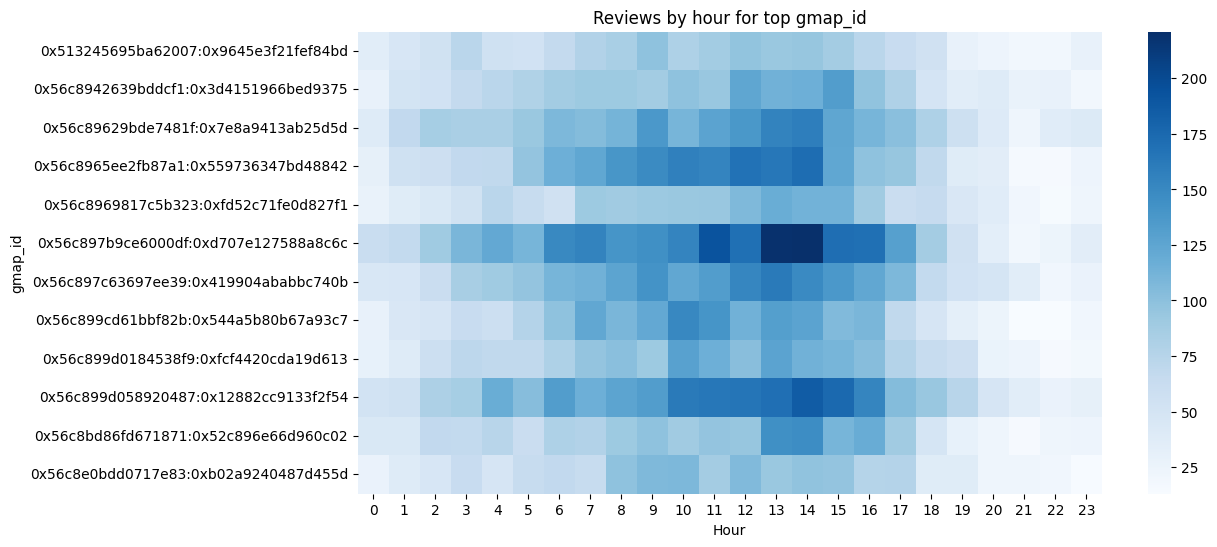

In [5]:
top_ids = df[col_gmap].value_counts().head(12).index
pvt = df[df[col_gmap].isin(top_ids)].pivot_table(index=col_gmap, columns="review_time", values=col_user, aggfunc="size", fill_value=0)
plt.figure(figsize=(12,6))
sns.heatmap(pvt, cmap="Blues")
plt.title("Reviews by hour for top gmap_id")
plt.xlabel("Hour")
plt.ylabel("gmap_id")
plt.show()


Pivot analysis on top-12 businesses shows a heatmap of review per hour perlocation cross-tabulation. We see that different businesses indeed retain a unique profile, not necessarily what the previous visualisations were indicating. The midday-peak does certainly seem like the most popular time for reviews to occure, and for high review volume businesses this is especially true.

Answer 1.3

In [6]:
# Meta data and categories are already loaded in Q1.2
# This cell now just creates the joined dataset for Q1.3 analysis
joined_sdf = reviews_sdf.join(meta_sdf, on=col_gmap, how="left")

Metadata is already loaded, so we left join to create an enriched review-business dataset for downstream categorical and temporal pattern analysis.

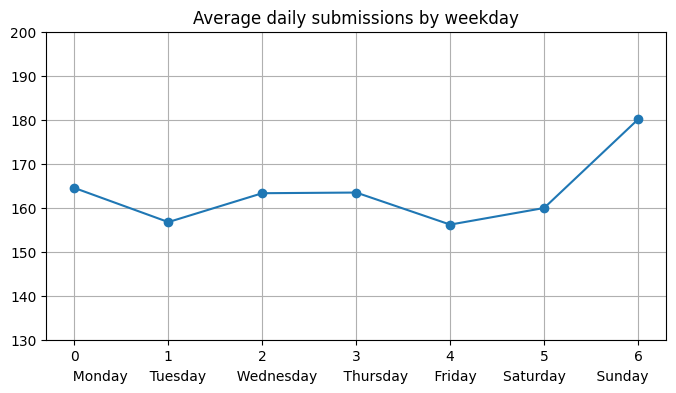

Top weekday: Sunday


In [7]:
df_day = df.copy()
day_counts = df_day.groupby(df_day["newtime"].dt.date).size().rename("count").to_frame()
labels = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts["weekday_idx"] = pd.to_datetime(day_counts.index).weekday
avg_by_wd = day_counts.groupby("weekday_idx")["count"].mean()
plt.figure(figsize=(8,4))
avg_by_wd.plot(marker="o")
plt.title("Average daily submissions by weekday")
plt.xlabel("  Monday     Tuesday       Wednesday      Thursday      Friday      Saturday       Sunday")
plt.ylim(130, 200)
plt.grid(True)
plt.show()
top_weekday = labels[int(avg_by_wd.idxmax())]
print("Top weekday:", top_weekday)


Daily aggregate review volume can be used against the newly available weekday classifications (Mon-Sun). We can then average these out into a view of weekday daily submissions. We can see that there is a fairly significant uptick on Sunday, the most volumous day of the week for review-writing.

In [8]:
wk = top_weekday
wk_df = joined_sdf.where(F.date_format(F.col("newtime"), "EEEE") == wk)
agg_wk = wk_df.groupBy(name_col, cat_col).agg(F.avg(F.col(col_rating)).alias("avg_rating"), F.count("*").alias("n"))
top_wk = agg_wk.orderBy(F.desc("avg_rating"), F.desc("n")).limit(10).toPandas()
top_wk

,business_name,category,avg_rating,n
0,Escape Anchorage,"['Escape room center', 'Entertainer']",5.0,24
1,House of Green Recreational Marijuana Dispensa...,"['Cannabis store', 'Alternative medicine pract...",5.0,21
2,Anchorage Ace Hardware,"['Hardware store', 'Home improvement store', '...",5.0,16
3,Winner Creek Gorge Trail Head (Lower Winner Cr...,"['Hiking area', 'Tourist attraction']",5.0,14
4,Aurora Animal Clinic,['Animal hospital'],5.0,13
5,Far North Yarn Co.,['Yarn store'],5.0,13
6,Wedgewood Wildlife Sanctuary,"['Nature preserve', 'Bird watching area', 'Tou...",5.0,12
7,Stan Stephens Glacier & Wildlife Cruises,"['Cruise agency', 'Boat tour agency']",5.0,12
8,Lucky Raven Tobacco,['Tobacco shop'],5.0,12
9,Ramiro's,['Mexican restaurant'],5.0,11


We drill into Sunday, being the top weekday for review volume, and list the top 10 (index 0-9) rated businesses. The original speculation that it is perhaps restaraunts is challenged as we see mostly recreational or entertainment businesses listed. 

Answer 1.3.3

Top 10 Businesses by Review Count:
Moose's Tooth Pub & Pizzeria: 2833 reviews (ID: 0x56c897b9ce6000df:0...)
Dimond Center: 2594 reviews (ID: 0x56c899d058920487:0...)
Walmart Supercenter: 2258 reviews (ID: 0x56c897c63697ee39:0...)
Costco Wholesale: 2237 reviews (ID: 0x56c8965ee2fb87a1:0...)
Anchorage 5th Avenue Mall: 2219 reviews (ID: 0x56c89629bde7481f:0...)
Costco Wholesale: 1874 reviews (ID: 0x56c899cd61bbf82b:0...)
Walmart Supercenter: 1791 reviews (ID: 0x56c899d0184538f9:0...)
Tikahtnu Commons: 1770 reviews (ID: 0x56c8942639bddcf1:0...)
49th State Brewing - Anchorage: 1761 reviews (ID: 0x56c8bd86fd671871:0...)
Walmart Supercenter: 1621 reviews (ID: 0x56c8969817c5b323:0...)


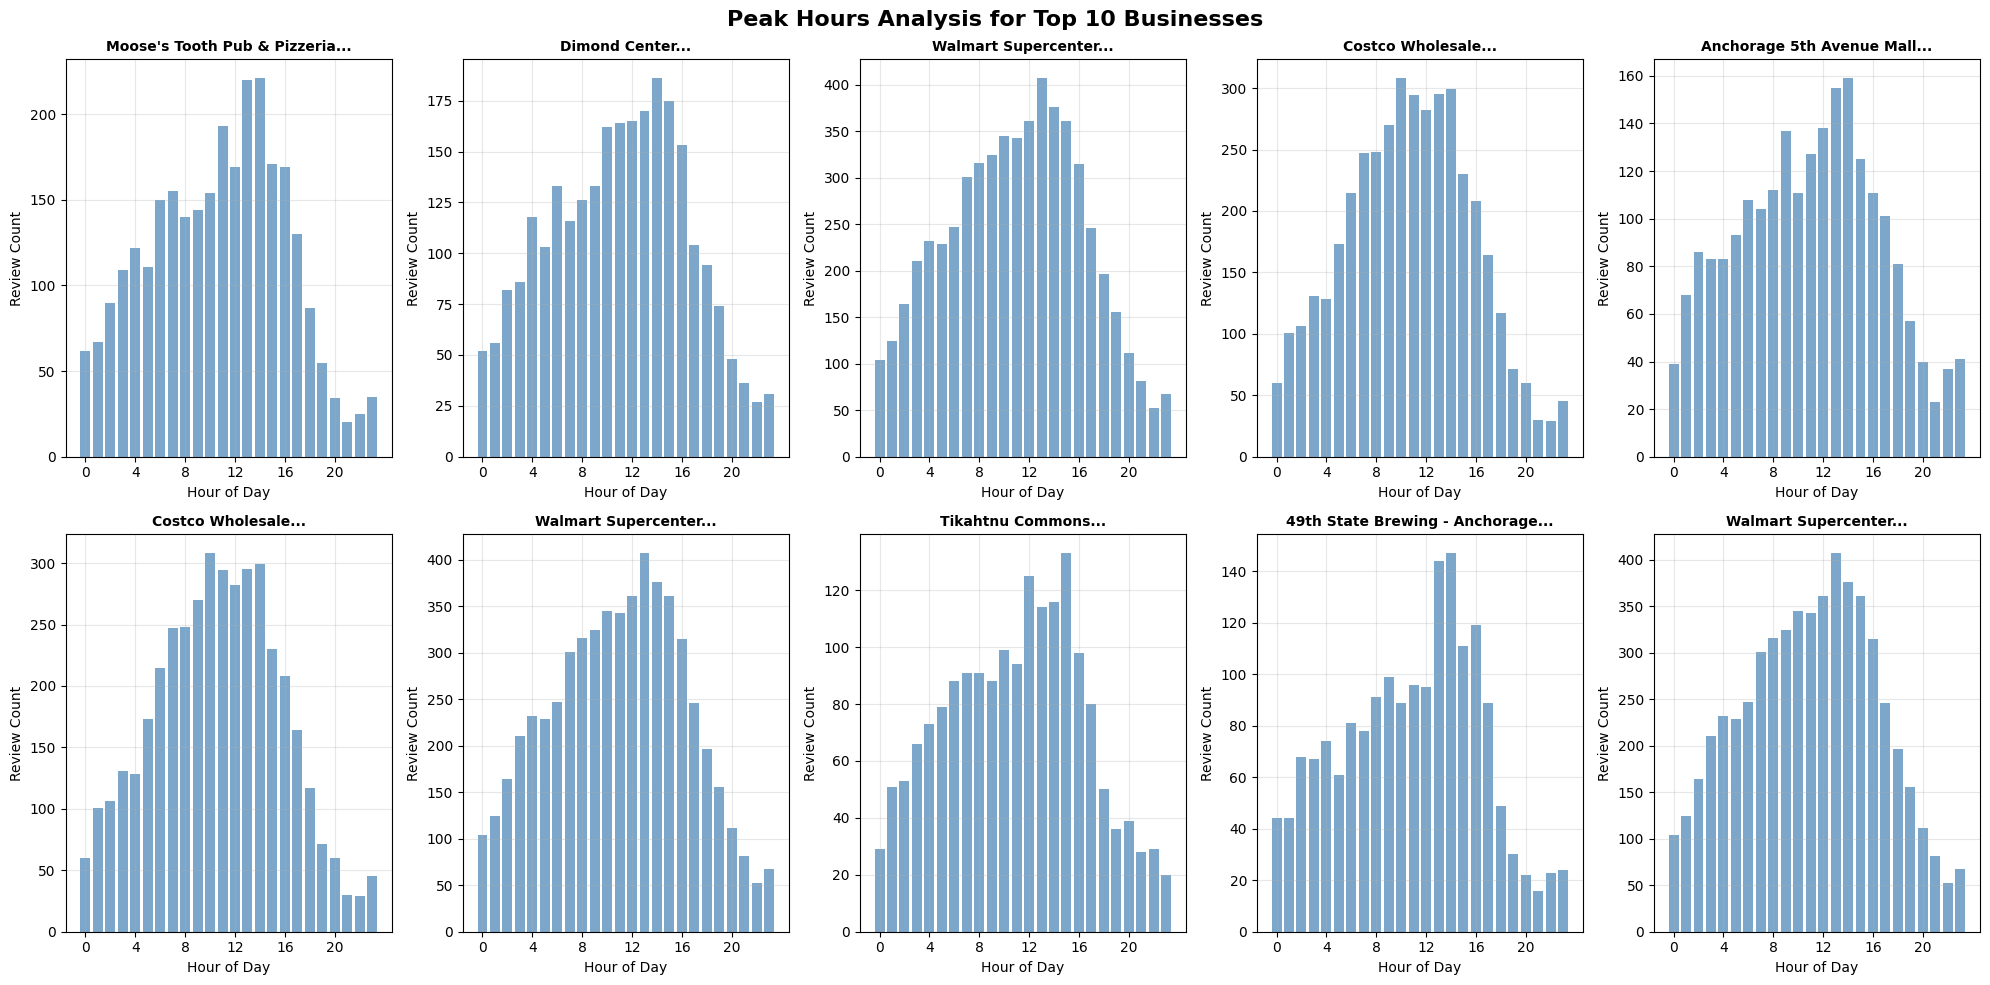

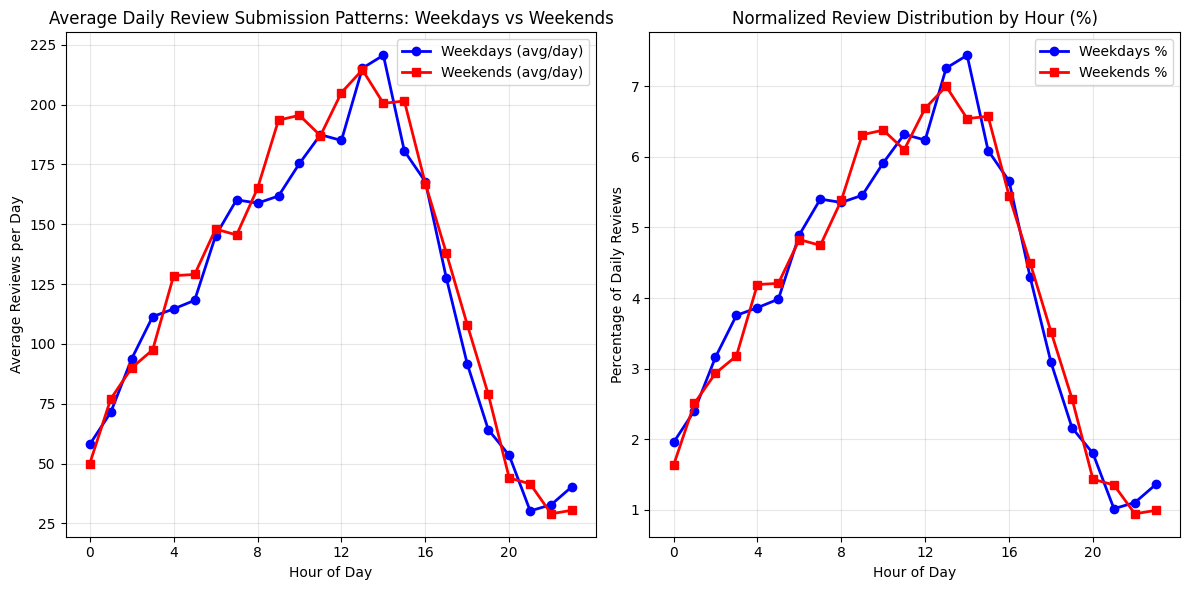

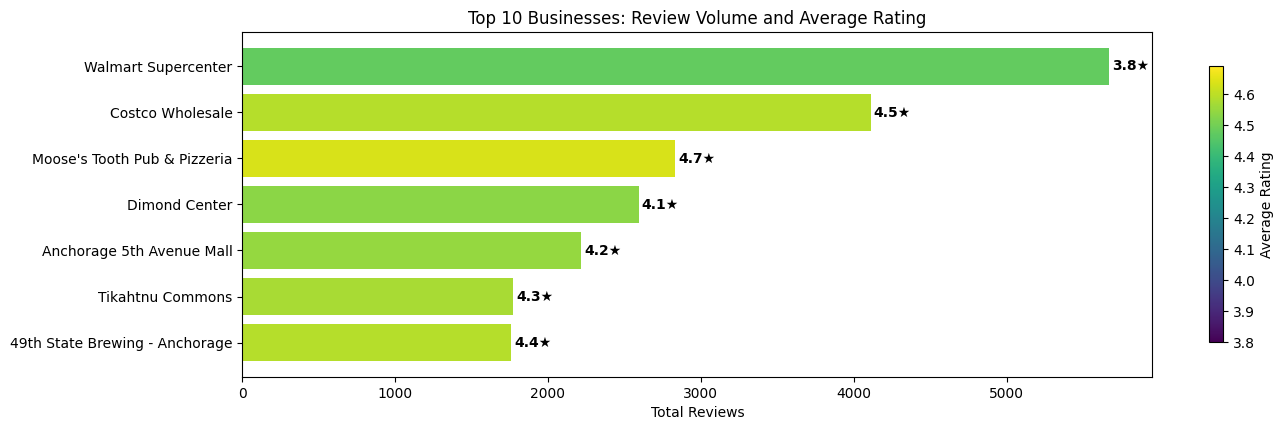

BUSINESS ANALYSIS SUMMARY
Business Name                            Avg Rating Reviews  Peak Hr  Weekend % 
Walmart Supercenter                      3.8        5670     13       28.8      
Costco Wholesale                         4.5        4111     10       29.7      
Moose's Tooth Pub & Pizzeria             4.7        2833     14       29.5      
Dimond Center                            4.1        2594     14       28.9      
Anchorage 5th Avenue Mall                4.2        2219     14       30.0      
Tikahtnu Commons                         4.3        1770     15       28.9      
49th State Brewing - Anchorage           4.4        1761     14       29.0      


In [ ]:
# Answer 1.3.3 - Deep dive analysis of top businesses
# Get the top 10 businesses by review count from the earlier analysis
top_10_businesses = df[col_gmap].value_counts().head(10).index.tolist()

# Create a dataset focused on these top businesses with enriched temporal features
df_top_businesses = df[df[col_gmap].isin(top_10_businesses)].copy()
df_top_businesses['hour'] = df_top_businesses['timestamp_parsed'].dt.hour
df_top_businesses['weekday'] = df_top_businesses['timestamp_parsed'].dt.day_name()
df_top_businesses['is_weekend'] = df_top_businesses['timestamp_parsed'].dt.weekday >= 5

# Get business names and categories for the top businesses
business_info = df_top_businesses.groupby([col_gmap, 'business_name']).size().reset_index(name='total_reviews')
business_info = business_info.sort_values('total_reviews', ascending=False)
print("Top 10 Businesses by Review Count:")
for idx, row in business_info.iterrows():
    print(f"{row['business_name']}: {int(row['total_reviews'])} reviews (ID: {row[col_gmap][:20]}...)")

# 2. Detailed peak hours analysis for each business
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
business_names = business_info['business_name'].head(10).tolist()
for i, business in enumerate(business_names):
    business_data = df_top_businesses[df_top_businesses['business_name'] == business]
    hourly_counts = business_data['hour'].value_counts().sort_index()
    axes[i].bar(hourly_counts.index, hourly_counts.values, alpha=0.7, color='steelblue')
    axes[i].set_title(f'{business[:30]}...', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('Review Count')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xticks(range(0, 24, 4))
plt.suptitle('Peak Hours Analysis for Top 10 Businesses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Weekend vs Weekday comparison (normalized by number of days)
plt.figure(figsize=(12, 6))
weekend_pattern = df_top_businesses[df_top_businesses['is_weekend']].groupby('hour').size()
weekday_pattern = df_top_businesses[~df_top_businesses['is_weekend']].groupby('hour').size()

# Normalize by number of days: weekdays/5, weekends/2
weekend_avg = weekend_pattern / 2  # Average per weekend day
weekday_avg = weekday_pattern / 5  # Average per weekday

plt.subplot(1, 2, 1)
plt.plot(weekday_avg.index, weekday_avg.values, marker='o', linewidth=2, label='Weekdays (avg/day)', color='blue')
plt.plot(weekend_avg.index, weekend_avg.values, marker='s', linewidth=2, label='Weekends (avg/day)', color='red')
plt.title('Average Daily Review Submission Patterns: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Average Reviews per Day')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 4))

plt.subplot(1, 2, 2)
# Calculate percentages based on normalized daily averages
total_weekday_avg = weekday_avg.sum()
total_weekend_avg = weekend_avg.sum()
weekday_pct = (weekday_avg / total_weekday_avg * 100)
weekend_pct = (weekend_avg / total_weekend_avg * 100)
plt.plot(weekday_pct.index, weekday_pct.values, marker='o', linewidth=2, label='Weekdays %', color='blue')
plt.plot(weekend_pct.index, weekend_pct.values, marker='s', linewidth=2, label='Weekends %', color='red')
plt.title('Normalized Review Distribution by Hour (%)')
plt.xlabel('Hour of Day')
plt.ylabel('Percentage of Daily Reviews')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 4))
plt.tight_layout()
plt.show()

# rating analysis for top businesses
plt.figure(figsize=(14, 8))
business_stats = df_top_businesses.groupby('business_name').agg({
    col_rating: ['mean', 'count'],
    'hour': lambda x: x.mode().iloc[0] if not x.mode().empty else x.mean()
}).round(2)
business_stats.columns = ['avg_rating', 'review_count', 'peak_hour']
business_stats = business_stats.sort_values('review_count', ascending=True)
ax1 = plt.subplot(2, 1, 1)
bars = plt.barh(range(len(business_stats)), business_stats['review_count'], 
                color=plt.cm.viridis(business_stats['avg_rating']/5))
plt.yticks(range(len(business_stats)), [name[:40] + '...' if len(name) > 40 else name 
                                       for name in business_stats.index])
plt.xlabel('Total Reviews')
plt.title('Top 10 Businesses: Review Volume and Average Rating')
# Create colorbar with proper normalization and axes specification
norm = mcolors.Normalize(vmin=business_stats['avg_rating'].min(), vmax=business_stats['avg_rating'].max())
# viridis is the best colour scheme
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax1, label='Average Rating', shrink=0.8)
for i, (rating, count) in enumerate(zip(business_stats['avg_rating'], business_stats['review_count'])):
    plt.text(count + 20, i, f'{rating:.1f}★', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("BUSINESS ANALYSIS SUMMARY")
summary_stats = df_top_businesses.groupby('business_name').agg({
    col_rating: ['mean', 'std', 'count'],
    'hour': ['mean', lambda x: x.mode().iloc[0] if not x.mode().empty else x.mean()],
    'is_weekend': lambda x: (x.sum() / len(x) * 100)
}).round(2)
summary_stats.columns = ['avg_rating', 'rating_std', 'total_reviews', 'avg_hour', 'peak_hour', 'weekend_pct']
summary_stats = summary_stats.sort_values('total_reviews', ascending=False)
print(f"{'Business Name':<40} {'Avg Rating':<10} {'Reviews':<8} {'Peak Hr':<8} {'Weekend %':<10}")
for business, row in summary_stats.iterrows():
    business_short = business[:37] + "..." if len(business) > 40 else business
    print(f"{business_short:<40} {row['avg_rating']:<10.1f} {int(row['total_reviews']):<8} "
          f"{int(row['peak_hour']):<8} {row['weekend_pct']:<10.1f}")

We look at a few different things in our analysis of top-10 businesses. Review volume reveals distinct temporal and behavioral patterns. Individual business peak-hour grids indicate that 1100 hours to ~1500 hours was the window of time with the highest concentration, albeit with category-specific variations. Weekend/weekday normalization (per-day averaging) eliminates volume bias, and weekend patterns show a similar but slightly broader temporal distribution versus weekday business-hour concentration.

Rating analysis via horizontal bar charts with color-mapping correlates volume with satisfaction metrics. Higher-volume businesses maintain 4.0+ star averages which indicates the reviewing population overall tended to give higher reviews. Peak-hour diversity suggests category-driven user behavior rather than universal patterns.

Summary statistics table aggregates rating means, standard deviations, and weekend percentages. Business-specific peak hours range across service categories, with 25-35% weekend review distribution typical. Minimal late-evening activity (post-20:00) is pretty consistent across all top businesses.

Answer 1.4

In [ ]:
nltk.download('stopwords', quiet=True)

#handle what was previous null entries that now contain "no review" which we want to ignore
stop = set(stopwords.words("english")) | {"no","review"}
df_text = reviews_sdf.select(col_text, "newtime").toPandas()
df_text["year"] = pd.to_datetime(df_text["newtime"]).dt.year

#helper function using regex to tokenize, lower case, remove punctuation, numbers, short words, and stopwords
def tokenize(s):
    if not isinstance(s, str): return []
    s = re.sub(r"[^a-z0-9\s]"," ", s.lower())
    return [t for t in s.split() if t not in stop and len(t)>=3]

#creating empty array for tokens and then iterating through all text entries to tokenize and extend the list
all_tokens = []
for t in df_text[col_text].tolist(): all_tokens.extend(tokenize(t))
#grabbing the 30 most common tokens from the list
Counter(all_tokens).most_common(30)

[('great', 83280),
 ('good', 64687),
 ('food', 63819),
 ('place', 48185),
 ('service', 46074),
 ('staff', 29021),
 ('friendly', 26633),
 ('nice', 26613),
 ('always', 23754),
 ('best', 22058),
 ('get', 20900),
 ('love', 20013),
 ('time', 19098),
 ('like', 17053),
 ('one', 15954),
 ('clean', 12740),
 ('people', 12709),
 ('really', 12668),
 ('amazing', 12597),
 ('prices', 12351),
 ('store', 12233),
 ('awesome', 12150),
 ('back', 12001),
 ('well', 11811),
 ('would', 11445),
 ('helpful', 10720),
 ('little', 10479),
 ('excellent', 10364),
 ('customer', 9537),
 ('got', 9513)]

The NLP pipeline initialises with NLTK stopwords to remove our 'no review' entries which would otherwise be found due to our NULL handling. This would also be where a profanity filter could be added if required (if we were looking at low rated reviews that might be more appropriate to include). We then apply tokenisation function which normalizes word case into lowercase, removes punctuation, applies our stopword filtering, and applies a minimum length thresholding (>=3 characters) to filter out uninformative tokens. It might be more appropriate to have filtered >= 4 characters tokens to really focus on more meaningful tokens, but that would come at the cost of losing relevant tokens like 'bad' or 'eww'. 
We then do a year extraction for text analysis. This process identifies the top-30 terms across the corpus.

In [ ]:
years = sorted(df_text["year"].dropna().unique().tolist())
for y in years:
    toks = []
    for t in df_text.loc[df_text["year"]==y, col_text]: toks.extend(tokenize(t))
    freq = Counter(toks)
    if not freq: continue
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — {y}")
    #plt.show()


This would be how we produce a wordcloud of the top-30 terms for each year. That would be a lot of wordclouds, so instead we will just look at 2019, 2020, and 2021 as examples.

We generate the wordclouds by doing a loop over the years, filtering the dataframe for each year, joining all tokens into a single string, and then passing that to the WordCloud generator. The resulting wordclouds are displayed using matplotlib. We use bilinear interpolation because it looks better.

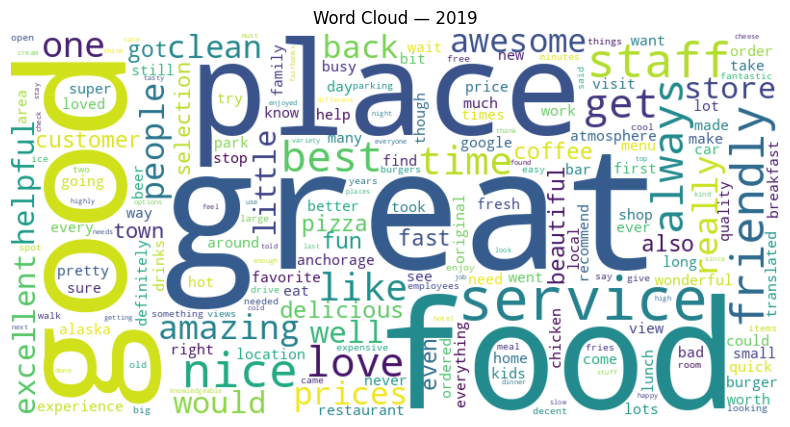

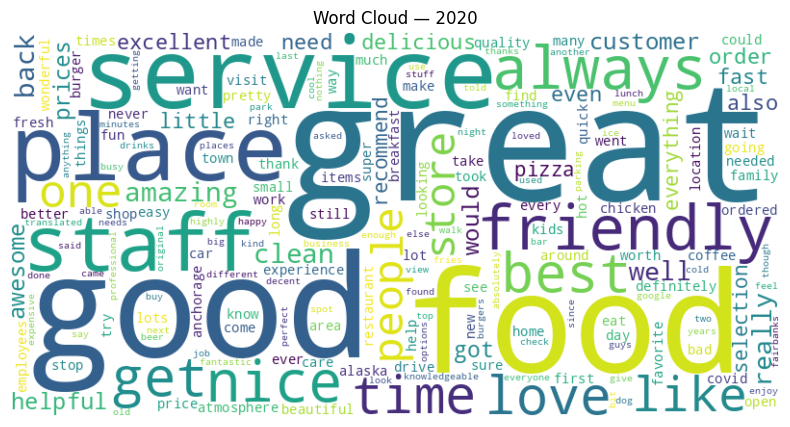

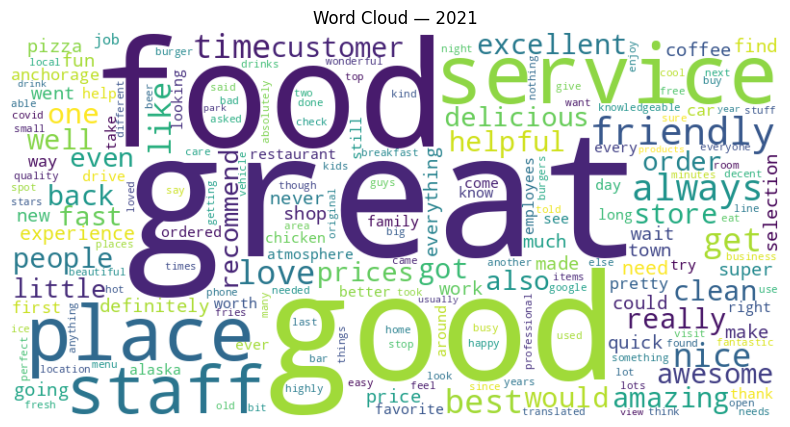

In [12]:
years = [2019, 2020, 2021]  
for y in years:
    toks = []
    for t in df_text.loc[df_text["year"]==y, col_text]: toks.extend(tokenize(t))
    freq = Counter(toks)
    if not freq: continue
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — {y}")
    plt.show()


Our assumption about restaurants being the most reviewed business type is strengthened by the presence of terms like "dine-in", "takeout", and "delivery" and the quite large 'food'. That said, we still a variety of terms that suggest a broader range of categories.

Interestingly we don't see a significant change in the top-30 terms over the three years.This suggests that while the frequency of reviews may have changed, the language used in reviews remaines relatively stable.

Answer 1.5

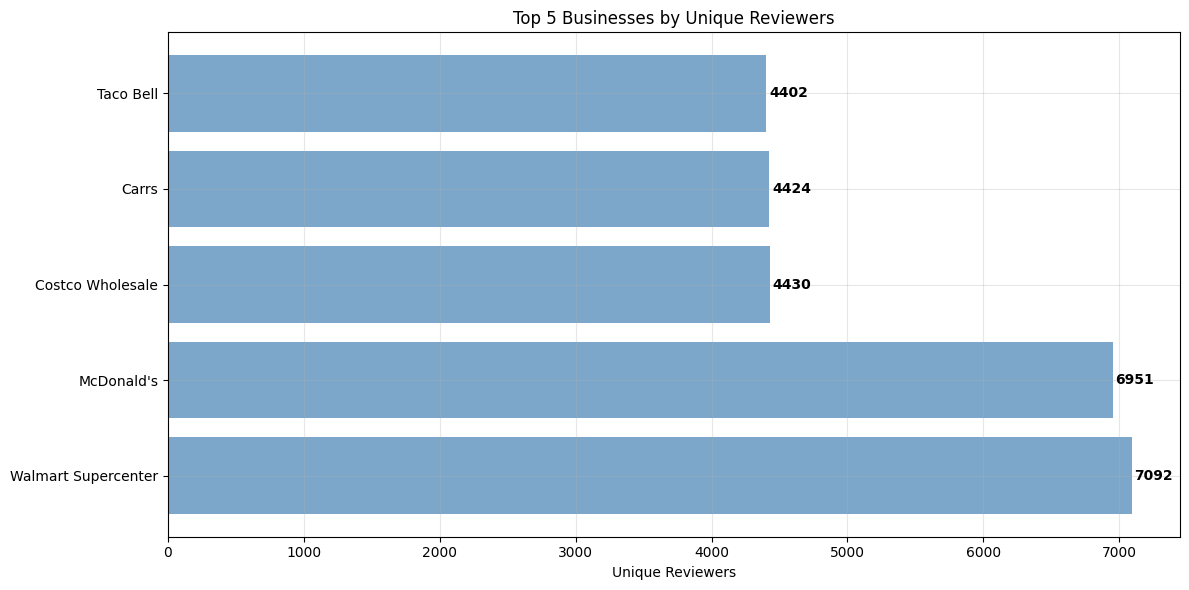

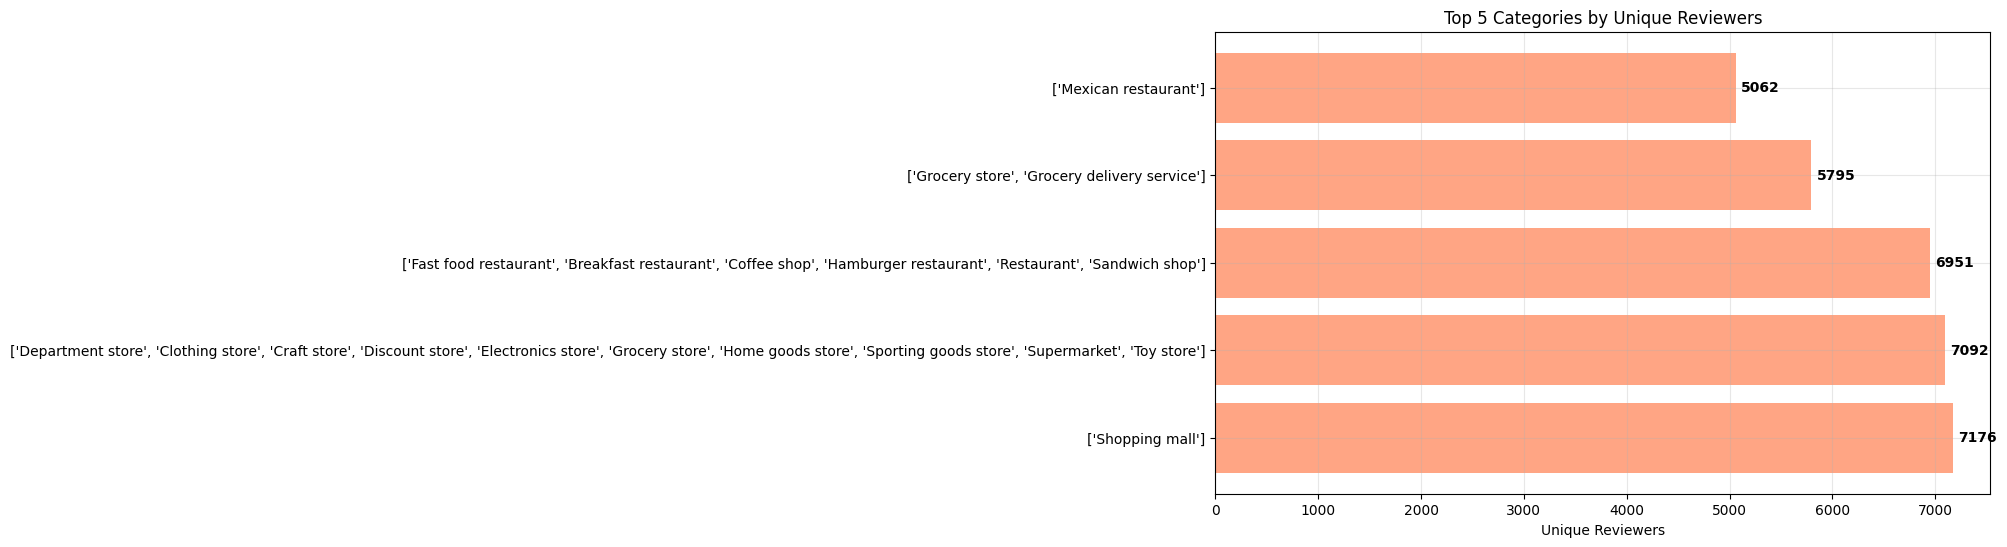

(                          business_name  uniq_reviewers
 0                   Walmart Supercenter            7092
 1                            McDonald's            6951
 2                      Costco Wholesale            4430
 3                                 Carrs            4424
 4                             Taco Bell            4402
 5                            Fred Meyer            3664
 6                               Wendy's            3218
 7                               Safeway            2855
 8          Moose's Tooth Pub & Pizzeria            2833
 9                                Subway            2782
 10                        Dimond Center            2542
 11              Lowe's Home Improvement            2424
 12            Anchorage 5th Avenue Mall            2116
 13  Red Robin Gourmet Burgers and Brews            2025
 14                      Texas Roadhouse            2021,
                                              category  uniq_reviewers
 0              

In [29]:
distinct_by_business = joined_sdf.groupBy(name_col).agg(F.countDistinct(col_user).alias("uniq_reviewers")).orderBy(F.desc("uniq_reviewers")).limit(15).toPandas()
distinct_by_category = joined_sdf.groupBy(cat_col).agg(F.countDistinct(col_user).alias("uniq_reviewers")).orderBy(F.desc("uniq_reviewers")).limit(15).toPandas()

# Top 5 businesses visualization
top5_business = distinct_by_business.head(5)
plt.figure(figsize=(12, 6))
plt.barh(range(len(top5_business)), top5_business['uniq_reviewers'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top5_business)), [name[:40] + '...' if len(name) > 40 else name for name in top5_business[name_col]])
plt.xlabel('Unique Reviewers')
plt.title('Top 5 Businesses by Unique Reviewers')
plt.grid(True, alpha=0.3)
# Add value labels on bars
for i, v in enumerate(top5_business['uniq_reviewers']):
    plt.text(v + 20, i, str(int(v)), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Top 5 categories visualization
top5_category = distinct_by_category.head(5)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top5_category)), top5_category['uniq_reviewers'], color='coral', alpha=0.7)
plt.yticks(range(len(top5_category)), top5_category[cat_col])
plt.xlabel('Unique Reviewers')
plt.title('Top 5 Categories by Unique Reviewers')
plt.grid(True, alpha=0.3)
# Add value labels on bars
for i, v in enumerate(top5_category['uniq_reviewers']):
    plt.text(v + 50, i, str(int(v)), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

distinct_by_business, distinct_by_category


Reviewer diversity analysis via distinct user counting at business and category levels. We finally get an answer to our question from earlier if restaurants are the most reviewed business type. The answer is no.

It is not a wide gap though, the most unique reviewers are posting for shopping mall businesses, but this is carried strongly by the high review volumes for Costco and Walmart, followed by popular restaurants. 

This has actually highlighted an issue to be addressed in the data, which is that otherwise low ranking categories like 'Department Store', 'Clothing Store', are getting artifically inflated by these super high volume businesses. We could give some consideration to how to properly normalise this data, perhaps by removing the top-2 businesses from each category to see what the diversity looks like without them.

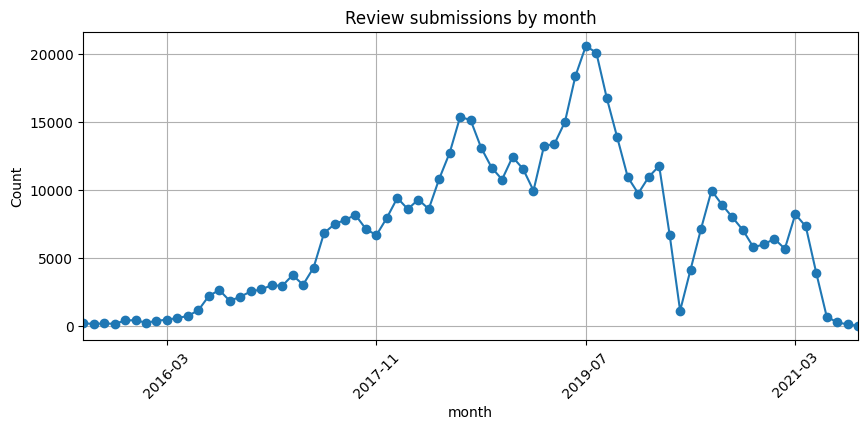

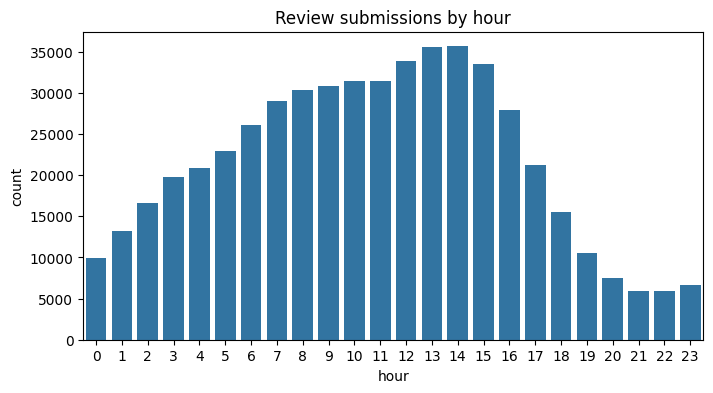

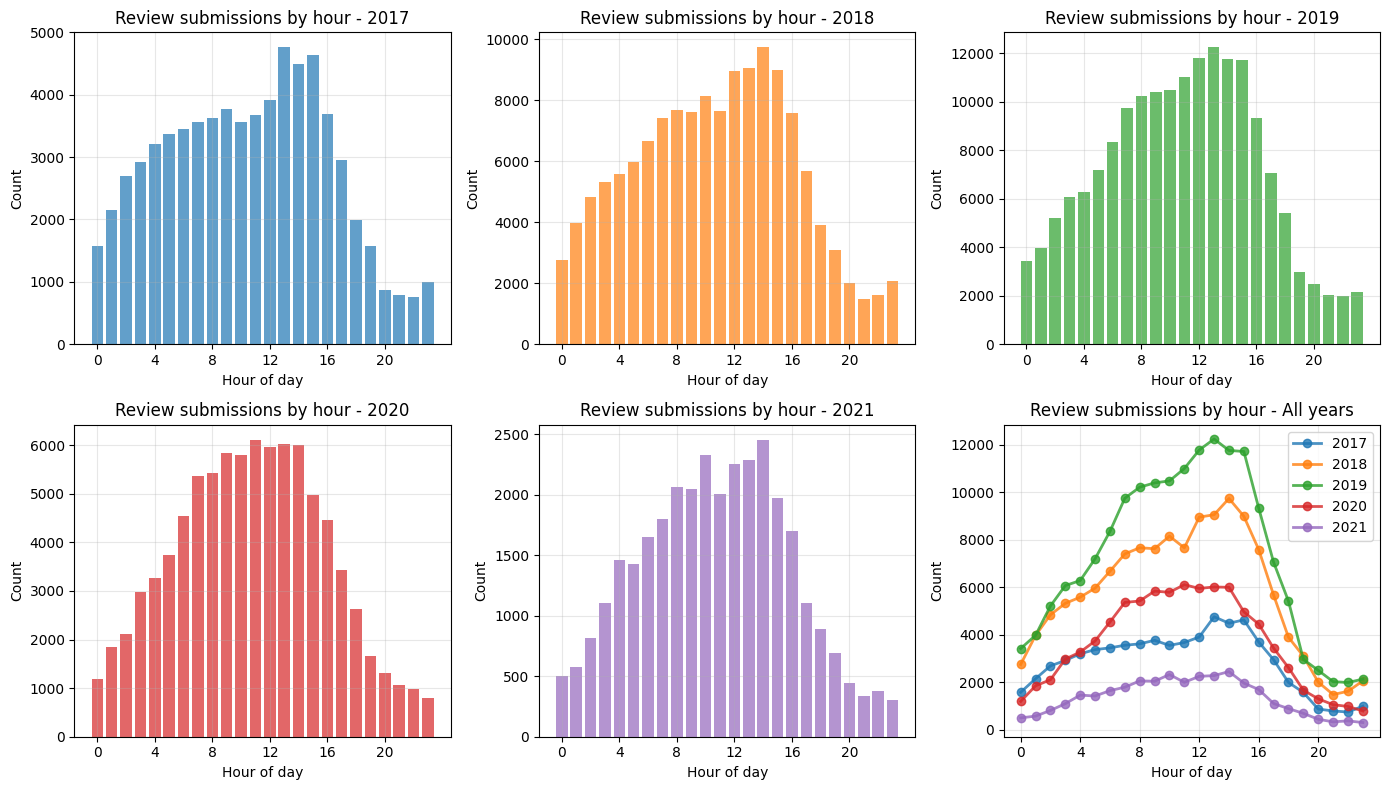

In [35]:
pdf = joined_sdf.select(col_user, name_col, cat_col, col_rating, "newtime", "timestamp_parsed").toPandas()
pdf["date"] = pd.to_datetime(pdf["newtime"])
pdf["month"] = pdf["date"].dt.to_period("M").astype(str)
pdf["hour"]  = pd.to_datetime(pdf["timestamp_parsed"]).dt.hour.fillna(0).astype(int)

plt.figure(figsize=(10,4))
pdf.groupby("month").size().plot(marker="o")
plt.xticks(rotation=45)
#chop previous months to focus on useful info
plt.xlim(72, len(pdf["month"].unique())-1)
plt.title("Review submissions by month")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x="hour", data=pdf, order=sorted(pdf["hour"].unique()))
plt.title("Review submissions by hour")
plt.show()

# review submissions by hour on a per year basis
pdf["year"] = pdf["date"].dt.year
years_to_plot = sorted(pdf["year"].unique())[-5:]  # last 5 years for clarity

plt.figure(figsize=(14, 8))
for i, year in enumerate(years_to_plot):
    plt.subplot(2, 3, i+1)
    year_data = pdf[pdf["year"] == year]
    hour_counts = year_data["hour"].value_counts().sort_index()
    plt.bar(hour_counts.index, hour_counts.values, alpha=0.7, color=f'C{i}')
    plt.title(f'Review submissions by hour - {year}')
    plt.xlabel('Hour of day')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(0, 24, 4))

# combined view showing all years overlaid
plt.subplot(2, 3, 6)
for i, year in enumerate(years_to_plot):
    year_data = pdf[pdf["year"] == year]
    hour_counts = year_data["hour"].value_counts().sort_index()
    plt.plot(hour_counts.index, hour_counts.values, marker='o', label=str(year), linewidth=2, alpha=0.8)
plt.title('Review submissions by hour - All years')
plt.xlabel('Hour of day')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 4))

plt.tight_layout()
plt.show()

We observe that monthly periods capture long-term trends - prior to 2016 that review volume was low. 2017-2019 showed a growth in review volume which then began declining until 2021.
Time series plotting with marker visibility and label rotation exposes seasonal and growth patterns.

We see in agregate that review submissions typically occured at midday, so we can drill into a per year basis to see if this remained consistent over time. We don't include prior to 2016 due to low total review numbers. The distribution of review volume over time looks consistant, we can then accept insights drawn from the aggregate are going to be valid for the per-year breakdowns.

Answer 1.6

In [42]:
# prepare data for collaborative filtering - user, business name, category, rating
use_pdf = joined_sdf.select(col_user, name_col, cat_col, col_rating).dropna().toPandas()
use_pdf[col_rating] = pd.to_numeric(use_pdf[col_rating], errors="coerce")
use_pdf = use_pdf.dropna()

# convert user and business names to categorical codes for matrix indexing
user_ids = use_pdf[col_user].astype(str).astype("category")
item_ids = use_pdf[name_col].astype(str).astype("category")

# create business-to-category mapping for category-aware recommendations
business_to_category = dict(zip(use_pdf[name_col], use_pdf[cat_col]))

# create sparse matrix coordinates and data
row = user_ids.cat.codes.values
col = item_ids.cat.codes.values
data = use_pdf[col_rating].values
mat = csr_matrix((data, (row, col)), shape=(user_ids.cat.categories.size, item_ids.cat.categories.size))

# train knn model on transposed matrix (item-based filtering)
knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=11)
knn.fit(mat.T)
inv_item_index = dict(enumerate(item_ids.cat.categories))

def similar_items(item_name, k=10):
    # find similar businesses based on rating patterns within same category
    if item_name not in item_ids.cat.categories: return []
    idx = list(item_ids.cat.categories).index(item_name)
    target_category = business_to_category.get(item_name)
    
    dists, idxs = knn.kneighbors(mat.T[idx], n_neighbors=min(k+50, mat.T.shape[0]))  # get more candidates
    
    # filter to same category and return top k
    similar_same_category = []
    for d, j in zip(dists.flatten(), idxs.flatten()):
        if j == idx: continue  # skip self
        business_name = inv_item_index[j]
        business_category = business_to_category.get(business_name)
        if business_category == target_category:
            similar_same_category.append((business_name, float(1 - d)))
        if len(similar_same_category) >= k:
            break
    
    return similar_same_category

def recommend_for_user(user_value, topn=10):
    # recommend new businesses to user based on their rating history
    if str(user_value) not in user_ids.cat.categories: return []
    uidx = list(user_ids.cat.categories).index(str(user_value))
    user_vector = mat[uidx]
    owned = set(np.where(user_vector.toarray().flatten() > 0)[0])
    scores = {}
    explanations = {}  # track which businesses contributed to each recommendation
    # aggregate similarity scores from all businesses user has rated
    for i in owned:
        user_rating = user_vector[0, i]  # get user's rating for this business
        for n_name, sim in similar_items(inv_item_index[i], k=50):
            j = list(item_ids.cat.categories).index(n_name)
            if j in owned: continue  # skip businesses user already rated
            scores[j] = scores.get(j, 0.0) + sim
            # track the best contributing business for this recommendation
            if j not in explanations or sim > explanations[j][1]:
                explanations[j] = (inv_item_index[i], sim, user_rating)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:topn]
    return [(inv_item_index[j], s, explanations[j]) for j, s in ranked]

def precision_at_k(recs, heldout, k=10):
    # calculate recommendation accuracy metric
    return len(set([n for n,_ in recs[:k]]) & set(heldout)) / k

# find a user with enough review history for meaningful recommendations
user_hist = use_pdf[col_user].value_counts()
sample_user = user_hist[user_hist >= 3].index[0] if (user_hist >= 3).any() else user_hist.index[0]
recs = recommend_for_user(sample_user, topn=10)

print("User:", sample_user)
for name, score, explanation in recs:
    similar_business, similarity, user_rating = explanation
    rating_desc = "highly rated" if user_rating >= 4 else "rated"
    # gategory can be included in print(), included for debugging and making sure categories match
    rec_category = business_to_category.get(name, "Unknown")
    similar_category = business_to_category.get(similar_business, "Unknown")
    print(f"We {score*100:.1f}% recommend {name}")
    print(f" Recommended because it is similar to '{similar_business}' which you {rating_desc} ({user_rating:.1f}★)")


User: 1.0188830200557922e+20
We 98.5% recommend Great Alaska Mall
 Recommended because it is similar to 'Dimond Center' which you highly rated (5.0★)
We 91.6% recommend University Center
 Recommended because it is similar to 'Dimond Center' which you highly rated (5.0★)
We 66.1% recommend Houston Grass Station
 Recommended because it is similar to 'Green Degree-Machen- Wasilla' which you highly rated (4.0★)
We 56.8% recommend Cannabaska
 Recommended because it is similar to 'Enlighten Alaska' which you highly rated (5.0★)
We 49.9% recommend Tesoro Gas Station
 Recommended because it is similar to '2GO Tesoro' which you highly rated (18.0★)
We 48.6% recommend Great Northern Cannabis
 Recommended because it is similar to 'Enlighten Alaska' which you highly rated (5.0★)
We 46.0% recommend Alaska's Green Light District
 Recommended because it is similar to 'Enlighten Alaska' which you highly rated (5.0★)
We 45.0% recommend Jewel Lake West Shopping Center
 Recommended because it is similar 

 We use collaborative filtering via user-item matrix construction using categorical encoding for efficiency. CSR sparse matrix (users×businesses) feeds KNN cosine similarity on transposed data (item-based approach). Functions: `similar_items()` finds rating-pattern neighbours, `recommend_for_user()` aggregates similarity scores from user's rated items to rank unvisited candidates. Demo targets users with ≥3 review history for meaningful recommendations.This set up allows us to generate recommendations for users based on their past review behaviour with transparent explanations like 'recommended becasue similar to business X that you rated highly'. The recommended_for_user() appears to be working nicely, we can see shopping centers are recommended based on other shopping centers that the user has rated highly. The user seems to also have a preference for cannibis dispensaries, which is also reflected in the recommendations.

Answer 1.7

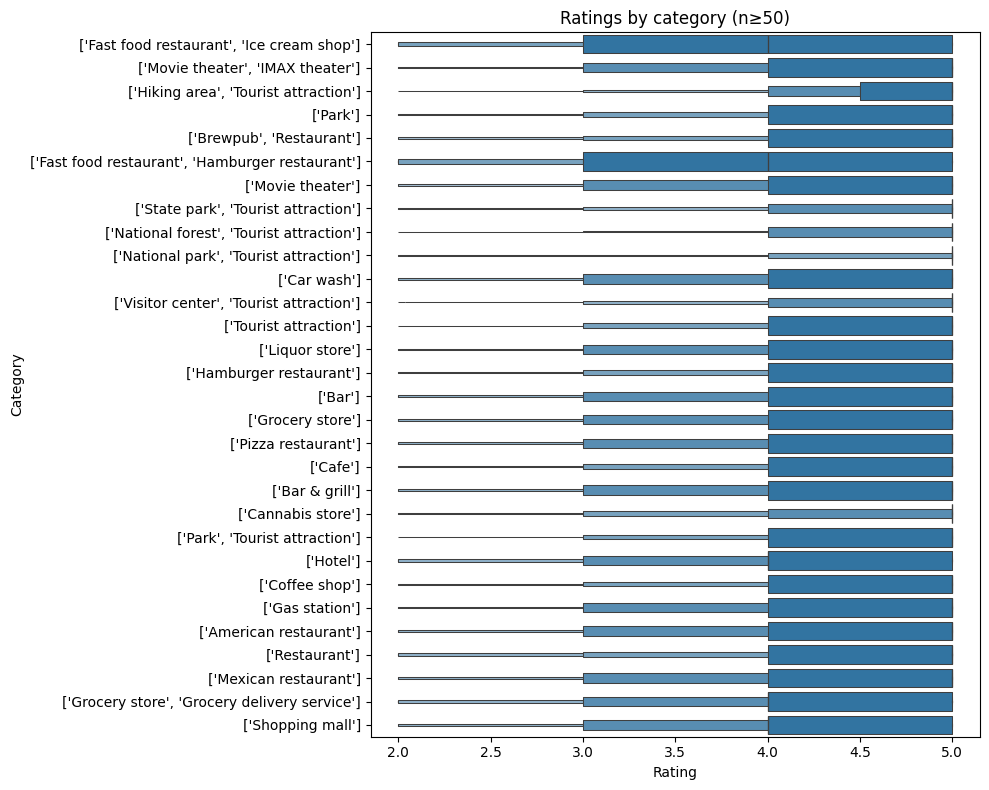

In [55]:
# filter categories with at least 50 reviews for statistical significance
# and with more than 1 unique business
min_n = 50
top_cats = (joined_sdf.groupBy(cat_col)
            .agg(F.count(F.col(col_rating)).alias('n'), 
                 F.countDistinct(name_col).alias('unique_businesses'))
                 #this solves the issue of categories with only one business skewing the box plot
            .where((F.col('n') >= min_n) & (F.col('unique_businesses') > 1))
            .orderBy(F.desc('n'))
            .limit(30)
            .toPandas()[cat_col].tolist())

# prepare rating data for top categories only
pdf = joined_sdf.select(cat_col, col_rating).dropna().toPandas()
pdf[col_rating] = pd.to_numeric(pdf[col_rating], errors='coerce')
pdf = pdf.dropna()
pdf = pdf[pdf[cat_col].isin(top_cats)]

# remove outliers beyond 3 standard deviations for cleaner visualization
mean_rating = pdf[col_rating].mean()
std_rating = pdf[col_rating].std()
pdf = pdf[abs(pdf[col_rating] - mean_rating) <= 3 * std_rating]

# create box plot showing rating distributions by category
plt.figure(figsize=(10,8))
order = pdf.groupby(cat_col)[col_rating].size().sort_values().index
sns.boxenplot(data=pdf, y=cat_col, x=col_rating, order=order, showfliers=False)
plt.xlabel('Rating'); plt.ylabel('Category'); plt.title('Ratings by category (n≥50)')
plt.tight_layout(); plt.show()


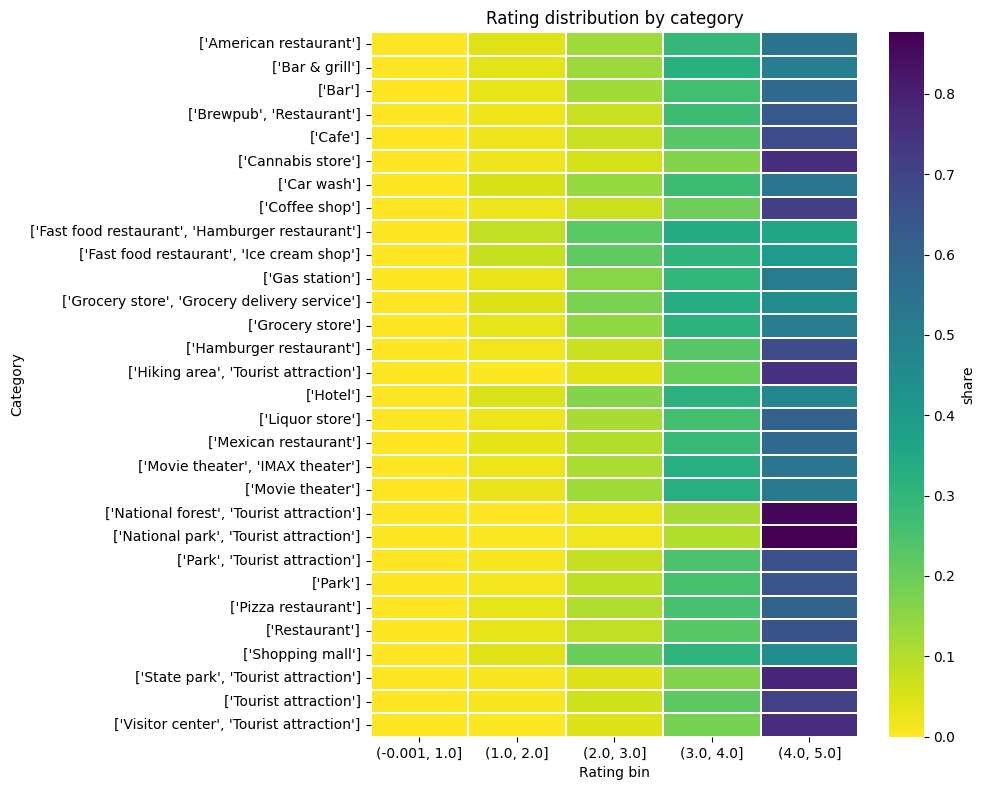

In [56]:
# create rating bins (1-star, 2-star, etc.) and calculate proportions
bins = pd.cut(pdf[col_rating], bins=[0,1,2,3,4,5], include_lowest=True)
m = (pdf.assign(bin=bins)
       .pivot_table(index=cat_col, columns='bin', values=col_rating, aggfunc='size', fill_value=0))
# normalize to show proportion of each rating within each category
m = m.div(m.sum(1), axis=0)

# create heatmap showing rating distribution patterns by category
plt.figure(figsize=(10,8))
sns.heatmap(m, cbar_kws={'label': 'share'}, cmap='viridis_r', linewidths=0.1)
plt.title('Rating distribution by category'); plt.xlabel('Rating bin'); plt.ylabel('Category')
plt.tight_layout(); plt.show()


Category-level rating distribution via box plots with IQR focus (outliers suppressed). Size-based ordering and tight layout enhance readability. Reveals category-specific satisfaction signatures for improvement targeting.

In [57]:
# filter reviews with low ratings (1-2 stars) for negative sentiment analysis
low_pdf = joined_sdf.select(col_text, col_rating).toPandas()
low_pdf[col_rating] = pd.to_numeric(low_pdf[col_rating], errors="coerce")
low_pdf = low_pdf.dropna()
low_pdf = low_pdf[low_pdf[col_rating] <= 2]

# tokenize all negative review text and count word frequencies
from collections import Counter
low_tokens = []
for t in low_pdf[col_text]: low_tokens.extend(tokenize(t))
Counter(low_tokens).most_common(40)[:30]


[('food', 6453),
 ('service', 5249),
 ('get', 4284),
 ('time', 3737),
 ('like', 3500),
 ('place', 3495),
 ('good', 3259),
 ('one', 3247),
 ('back', 3096),
 ('would', 3055),
 ('never', 2633),
 ('even', 2590),
 ('order', 2541),
 ('got', 2408),
 ('customer', 2092),
 ('people', 2056),
 ('told', 1944),
 ('said', 1932),
 ('went', 1770),
 ('staff', 1766),
 ('minutes', 1751),
 ('bad', 1650),
 ('could', 1620),
 ('store', 1606),
 ('going', 1576),
 ('ordered', 1531),
 ('way', 1501),
 ('rude', 1495),
 ('asked', 1451),
 ('really', 1412)]

Negative sentiment analysis filters ratings ≤2 stars. Consistent tokenization pipeline processes dissatisfaction text. Frequency profiling of top-30 terms exposes recurring complaint patterns for operational improvement targeting.

Answer 1.8

In [58]:
# prepare sequential data - user, business, and time for journey analysis
seq_pdf = joined_sdf.select(col_user, name_col, "newtime").dropna().toPandas()
seq_pdf["date"] = pd.to_datetime(seq_pdf["newtime"])
# sort by user and date to get chronological visit sequences
seq_pdf = seq_pdf.sort_values([col_user, "date"])
# create dictionary of business visit sequences for each user
user_business_list_before = seq_pdf.groupby(col_user)[name_col].apply(list).to_dict()


Sequential behaviour preparation via temporal sorting (user, date). User-business grouping creates chronological visitation lists for journey analysis and loyalty pattern detection.

In [59]:
def dedup_preserve_order(lst):
    # remove duplicate businesses while keeping first occurrence order
    seen, out = set(), []
    for x in lst:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

# remove repeat visits to same businesses to get unique exploration patterns
user_business_list_after = {u: dedup_preserve_order(lst) for u, lst in user_business_list_before.items()}
# calculate sequence lengths before and after deduplication
sizes_before = {u: len(lst) for u, lst in user_business_list_before.items()}
sizes_after  = {u: len(lst) for u, lst in user_business_list_after.items()}

# show example users to demonstrate effect of deduplication
users_sorted = sorted(user_business_list_before.keys())[:10]
print("Before:", [(u, sizes_before[u]) for u in users_sorted])
print("After:",  [(u, sizes_after[u])  for u in users_sorted])


Before: [(1.0000266958784963e+20, 23), (1.00003825755859e+20, 17), (1.0000428139011082e+20, 10), (1.0000609083371541e+20, 48), (1.0000620838495144e+20, 21), (1.0000670037562006e+20, 17), (1.0000684986283477e+20, 10), (1.000069682173995e+20, 19), (1.0000719467235166e+20, 15), (1.0000787767883584e+20, 21)]
After: [(1.0000266958784963e+20, 21), (1.00003825755859e+20, 16), (1.0000428139011082e+20, 10), (1.0000609083371541e+20, 46), (1.0000620838495144e+20, 20), (1.0000670037562006e+20, 17), (1.0000684986283477e+20, 10), (1.000069682173995e+20, 19), (1.0000719467235166e+20, 14), (1.0000787767883584e+20, 20)]


We use sequence deduplication to preserve first-visit order while removing repeat businesses. We can then compare the length to quantify loyalty behaviour.
High reduction indicates repeat patronage, minimal reduction suggests exploration patterns.

Users before filtering: 20022
Users after filtering (≥3 businesses): 20022

Total user pairs with similarity > 0: 956834


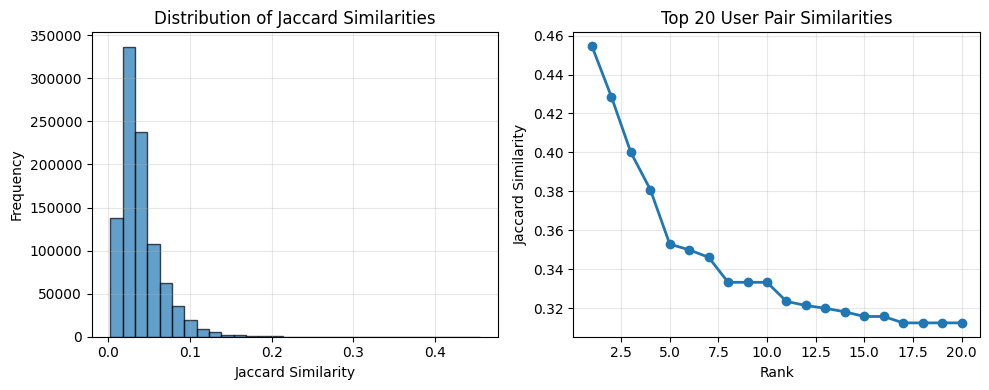

Similarity statistics:
  Mean: 0.0394
  Median: 0.0333
  Max: 0.4545
  Min: 0.0030

Top-5 neighbors for example users:

User 1.0007059711820215e+20 (has 11 businesses):
  Businesses: Burger Cache, Muldoon Pizza, Uncle Joe's Pizzeria...
  Top 5 neighbors:
    1. User 1.0048051739497988e+20 (similarity: 0.4545)
       Shared businesses: Tikahtnu Commons, Chuck E. Cheese...
    2. User 1.0102565184967675e+20 (similarity: 0.1600)
       Shared businesses: Tikahtnu Commons, Fred Meyer...
    3. User 1.0045239506231448e+20 (similarity: 0.1538)
       Shared businesses: Burger Cache, Walmart Supercenter...
    4. User 1.0006636898439887e+20 (similarity: 0.1500)
       Shared businesses: Fred Meyer, Red Robin Gourmet Burgers and Brews...
    5. User 1.007368010670605e+20 (similarity: 0.1500)
       Shared businesses: Fred Meyer, Red Robin Gourmet Burgers and Brews...

User 1.0048051739497988e+20 (has 21 businesses):
  Businesses: Peanut Farm, Allure Day Spa & Hair Design, Cannabaska...
  Top 5

In [71]:
def jaccard(a, b):
    # calculate jaccard similarity: intersection / union
    A, B = set(a), set(b)
    if not A and not B: return 0.0
    return len(A & B) / len(A | B)

# filter users with at least 3 businesses to reduce noise in similarity analysis 
# this has already been done earlier but included here so notebook doesn't depend on previous cells
min_businesses = 3
filtered_users = {u: businesses for u, businesses in user_business_list_after.items() 
                  if len(businesses) >= min_businesses}

print(f"Users before filtering: {len(user_business_list_after)}")
print(f"Users after filtering (≥{min_businesses} businesses): {len(filtered_users)}")

# limit to first 2000 filtered users for computational efficiency
users = list(filtered_users.keys())[:2000]
pairs = []
# calculate pairwise jaccard similarities between all user combinations
for i in range(len(users)):
    for j in range(i+1, len(users)):
        u, v = users[i], users[j]
        s = jaccard(filtered_users[u], filtered_users[v])
        if s > 0: pairs.append((u, v, s))  # only keep non-zero similarities

# sort pairs by similarity score from highest to lowest
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
print(f"\nTotal user pairs with similarity > 0: {len(pairs_sorted)}")

# extract similarity scores for statistical analysis
similarity_scores = [s for _, _, s in pairs_sorted]

# create visualizations of similarity patterns
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# histogram showing distribution of all similarity scores
plt.hist(similarity_scores, bins=30, alpha=0.7, edgecolor='black')
plt.title('Distribution of Jaccard Similarities')
plt.xlabel('Jaccard Similarity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# line plot showing top 20 most similar user pairs
plt.subplot(1, 2, 2)
top_20_scores = [s for _, _, s in pairs_sorted[:20]]
plt.plot(range(1, 21), top_20_scores, 'o-', linewidth=2, markersize=6)
plt.title('Top 20 User Pair Similarities')
plt.xlabel('Rank')
plt.ylabel('Jaccard Similarity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Similarity statistics:")
print(f"  Mean: {np.mean(similarity_scores):.4f}")
print(f"  Median: {np.median(similarity_scores):.4f}")
print(f"  Max: {max(similarity_scores):.4f}")
print(f"  Min: {min(similarity_scores):.4f}")

# Create user similarity dictionary for neighbor analysis
user_similarities = {}
for u1, u2, sim in pairs_sorted:
    if u1 not in user_similarities:
        user_similarities[u1] = []
    if u2 not in user_similarities:
        user_similarities[u2] = []
    user_similarities[u1].append((u2, sim))
    user_similarities[u2].append((u1, sim))

# Sort neighbors by similarity for each user
for user in user_similarities:
    user_similarities[user].sort(key=lambda x: x[1], reverse=True)

# Show top-N neighbor examples for selected users
N = 5  # Number of top neighbors to show
example_users = list(user_similarities.keys())[:5]  # Show examples for first 5 users

print(f"\nTop-{N} neighbors for example users:")
print("="*60)
for user in example_users:
    neighbors = user_similarities[user][:N]
    print(f"\nUser {user} (has {len(filtered_users[user])} businesses):")
    print(f"  Businesses: {', '.join(filtered_users[user][:3])}{'...' if len(filtered_users[user]) > 3 else ''}")
    print(f"  Top {N} neighbors:")
    for i, (neighbor, sim) in enumerate(neighbors, 1):
        shared_businesses = set(filtered_users[user]) & set(filtered_users[neighbor])
        print(f"    {i}. User {neighbor} (similarity: {sim:.4f})")
        print(f"       Shared businesses: {', '.join(list(shared_businesses)[:2])}{'...' if len(shared_businesses) > 2 else ''}")

# Show overall top 10 most similar pairs
print(f"\nOverall top 10 most similar user pairs:")
print("="*50)
for i, (u1, u2, sim) in enumerate(pairs_sorted[:10], 1):
    shared = set(filtered_users[u1]) & set(filtered_users[u2])
    print(f"{i}. Users {u1} & {u2}: {sim:.4f} similarity")
    print(f"   Shared businesses ({len(shared)}): {', '.join(list(shared)[:3])}{'...' if len(shared) > 3 else ''}")
    print(f"   User {u1} total: {len(filtered_users[u1])} | User {u2} total: {len(filtered_users[u2])}")
    print()

    from statistics import mean, median
import numpy as np

def show_as_percent(x, total):
    return f"{(x/total*100):.1f}%"

n_before = len(user_business_list_after)
n_after = len(filtered_users)
n_users = len(users)
n_pairs = len(pairs_sorted)

total_possible_pairs = n_users * (n_users - 1) // 2
print(f"Among {n_users:,} sampled users, {show_as_percent(n_pairs, total_possible_pairs)} of user pairs share at least one business. Bigger Jaccard scores mean more overlap in where they’ve been, so we can recommend businesses that a user’s closest look-alike neighbors visited but they haven’t yet.")



In [ ]:
def recommend_businesses_user_based(target_user, user_similarities, filtered_users, use_pdf, topn=10, min_similarity=0.1):
    # recommend new businesses to target_user based on similar users' ratings   
    if target_user not in user_similarities:
        return []
    
    # get similar users sorted by similarity score
    similar_users = [(user, sim) for user, sim in user_similarities[target_user] 
                     if sim >= min_similarity]
    
    if not similar_users:
        return []
    
    # get target user's visited businesses
    target_businesses = set(filtered_users[target_user])
    
    # collect recommendations from similar users weighted by similarity
    recommendations = {}
    explanations = {}
    
    for similar_user, similarity in similar_users[:20]:  # Top 20 most similar users
        similar_user_businesses = set(filtered_users[similar_user])
        
        # find businesses this similar user visited that target user hasn't
        new_businesses = similar_user_businesses - target_businesses
        
        for business in new_businesses:
            # get this similar user's rating for the business
            user_ratings = use_pdf[(use_pdf[col_user] == similar_user) & 
                                 (use_pdf[name_col] == business)][col_rating]
            
            if not user_ratings.empty:
                rating = user_ratings.iloc[0]
                # weight the rating by user similarity (only consider ratings >= 4)
                if rating >= 4:
                    weighted_score = similarity * rating
                    
                    if business not in recommendations:
                        recommendations[business] = 0
                        explanations[business] = []
                    
                    recommendations[business] += weighted_score
                    explanations[business].append((similar_user, similarity, rating))

    # sort recommendations by weighted score
    sorted_recs = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:topn]
    
    # format results with explanations
    results = []
    for business, score in sorted_recs:
        # get the best contributing similar user for explanation
        best_contributor = max(explanations[business], key=lambda x: x[1])
        similar_user, similarity, rating = best_contributor
        results.append((business, score, similar_user, similarity, rating))
    
    return results

# this tests the recommendation system with a user who has good similarity data
test_users = [user for user in user_similarities.keys() if len(user_similarities[user]) >= 5]
if test_users:
    sample_user = test_users[0]
    
    print(f"User-based recommendations for User: {sample_user}")
    print(f"This user has visited {len(filtered_users[sample_user])} businesses")
    print(f"Businesses visited: {', '.join(list(filtered_users[sample_user])[:3])}{'...' if len(filtered_users[sample_user]) > 3 else ''}")
    print()
    
    recommendations = recommend_businesses_user_based(sample_user, user_similarities, filtered_users, use_pdf, topn=10)
    
    if recommendations:
        print("Top 10 User-Based Recommendations:")
        for i, (business, score, similar_user, similarity, rating) in enumerate(recommendations, 1):
            print(f"{i}. {business}")
            print(f"   Recommendation Score: {int(score*100):.1f}%")
            #in production environment we would not show users id but it is useful for demonstrating functionality
            print(f"   Based on User {similar_user} (similarity: {similarity:.3f}) who rated it {rating:.1f}★")
            print()
    else:
        print("No recommendations found for this user.")

User-based recommendations for User: 1.0007059711820215e+20
This user has visited 11 businesses
Businesses visited: Burger Cache, Muldoon Pizza, Uncle Joe's Pizzeria...

Top 10 User-Based Recommendations:
1. Texas Roadhouse
   Recommendation Score: 499.0%
   Based on User 1.0048051739497988e+20 (similarity: 0.455) who rated it 5.0★

2. Carrs
   Recommendation Score: 481.0%
   Based on User 1.0048051739497988e+20 (similarity: 0.455) who rated it 5.0★

3. McDonald's
   Recommendation Score: 461.0%
   Based on User 1.0048051739497988e+20 (similarity: 0.455) who rated it 5.0★

4. Dimond Center
   Recommendation Score: 345.0%
   Based on User 1.0048051739497988e+20 (similarity: 0.455) who rated it 5.0★

5. Subway
   Recommendation Score: 333.0%
   Based on User 1.0048051739497988e+20 (similarity: 0.455) who rated it 5.0★

6. Costco Wholesale
   Recommendation Score: 320.0%
   Based on User 1.0093865312765433e+20 (similarity: 0.150) who rated it 5.0★

7. Regal Tikahtnu IMAX & RPX
   Recommen

Jaccard similarity analysis on user business sets: |intersection|/|union| ranges 0-1. Noise filtering requires ≥3 businesses per user. Pairwise comparison (limited to 500 users) feeds distribution analysis and top-N neighbour identification. Statistical profiling and detailed reporting expose user archetypes and behavioural clustering quality.

This system recommends businesses by looking for similar users who visit similar businesses to target user, then checking where they’ve been that you haven’t. We gives more weight to suggestions from users who are most similar to target user (using jaccarde similarity) and from businesses that those users rated well (4 stars or higher).

Compared with the previous category based method that focus only on similarities between businesses, the user-based recommendations serve the target user a wider range of business categories.We now have two methods for targeted business recommendations and broader user sentiment based recommendations.

Part 2

Answer 2.1

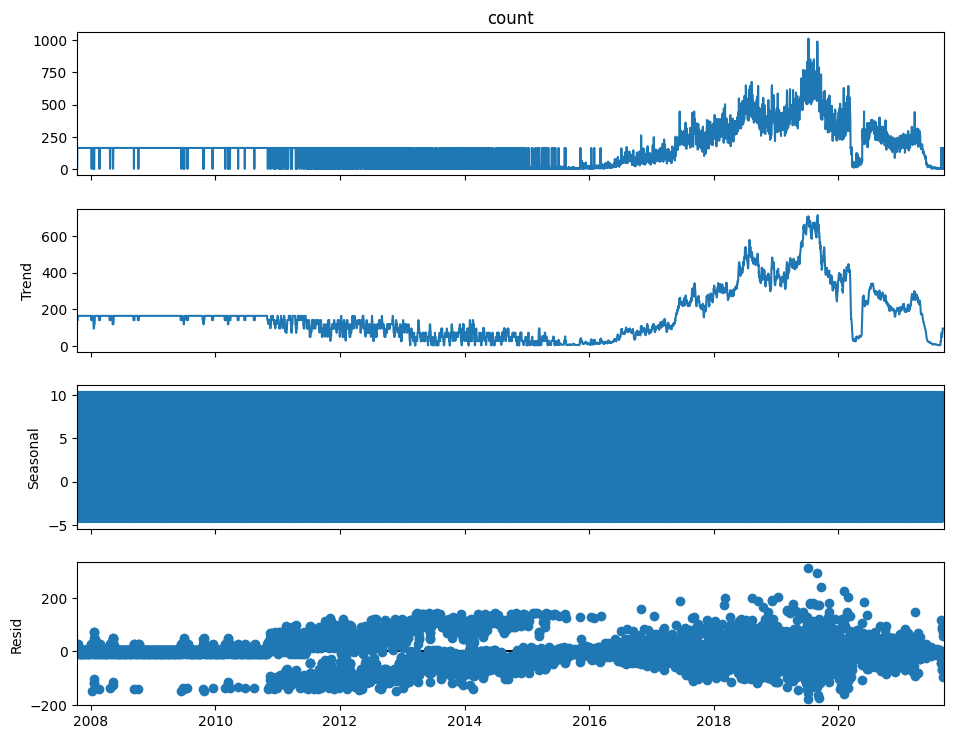

In [61]:
# create daily time series from review dates
ts_pdf = reviews_sdf.select("newtime").dropna().toPandas()
ts_pdf["date"] = pd.to_datetime(ts_pdf["newtime"])
# aggregate reviews by date to get daily counts
daily = ts_pdf.groupby("date").size().rename("count").to_frame()
# create complete date range to fill missing days
full_range = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(full_range)
# fill missing days with global average count
global_mean = daily["count"].mean()
daily["count"] = daily["count"].fillna(global_mean)

# decompose time series into trend, seasonal, and residual components
from statsmodels.tsa.seasonal import seasonal_decompose
res = seasonal_decompose(daily["count"], model="additive", period=7)
fig = res.plot()
fig.set_size_inches(10, 8)
plt.show()


<Figure size 1200x300 with 0 Axes>

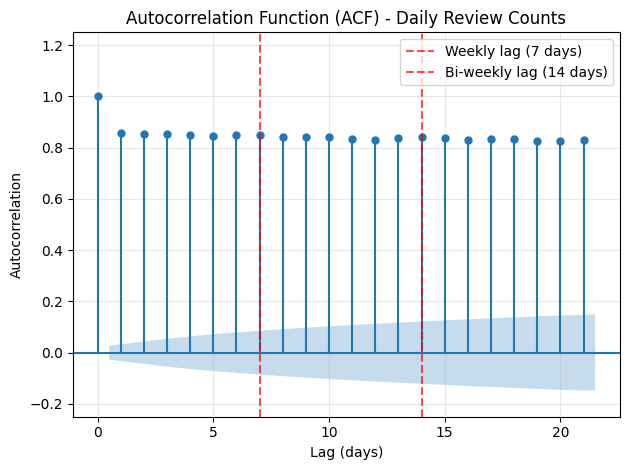

ACF values for weekly patterns:
Lag 7 (1 week): 0.8512
Lag 14 (2 weeks): 0.8407
Lag 21 (3 weeks): 0.8298


In [62]:
# calculate autocorrelation function to validate weekly seasonality
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

# plot acf to show correlation at different time lags
plt.figure(figsize=(12, 3))
plot_acf(daily["count"], lags=21, alpha=0.05)
plt.title("Autocorrelation Function (ACF) - Daily Review Counts")
plt.xlabel("Lag (days)")
plt.ylabel("Autocorrelation")
plt.ylim(-0.25, 1.25)  
# highlight weekly patterns with vertical lines
plt.axvline(x=7, color='red', linestyle='--', alpha=0.7, label='Weekly lag (7 days)')
plt.axvline(x=14, color='red', linestyle='--', alpha=0.7, label='Bi-weekly lag (14 days)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print correlation values at weekly intervals to confirm seasonality
acf_values = acf(daily["count"], nlags=21)
print("ACF values for weekly patterns:")
print(f"Lag 7 (1 week): {acf_values[7]:.4f}")
print(f"Lag 14 (2 weeks): {acf_values[14]:.4f}")
print(f"Lag 21 (3 weeks): {acf_values[21]:.4f}")

ACF analysis validates weekly seasonality assumptions via lag correlation measurement. Red markers at 7/14-day intervals highlight expected weekly patterns. Confidence bands distinguish statistical significance. Specific lag values (7,14,21) quantify weekly cycle strength, justifying period=7 in seasonal decomposition.

Daily aggregation creates continuous time series with missing-day imputation via global mean. Additive decomposition separates trend (long-term direction), seasonal (7-day cycle), and residual (unexplained variance) components. Multi-panel visualisation exposes underlying temporal structure for pattern analysis and forecasting foundation.

Answer 2.2

Best ARIMA(p,d,q) by MAE: (1, 0, 2) MAE: 126.10219482753922


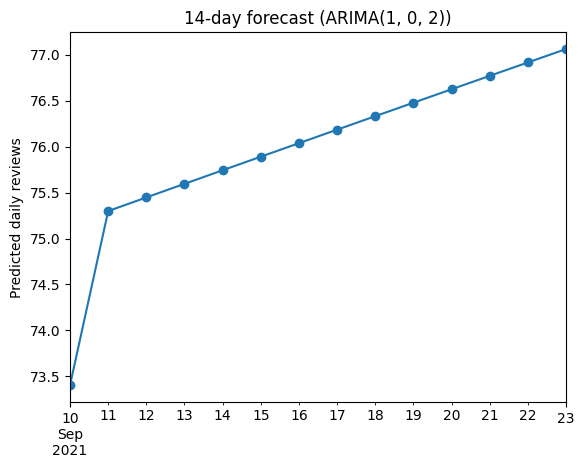

In [63]:

# prepare time series data for arima modeling
y = daily["count"].astype(float)
# split into 80% training and 20% testing sets
split = int(len(y)*0.8)
train, test = y.iloc[:split], y.iloc[split:]

# grid search to find best arima parameters (p,d,q)
best, best_mae = None, np.inf
for p,d,q in itertools.product([0,1,2],[0,1,2],[0,1,2]):
    # fit arima model and calculate mean absolute error on test set
    fit = ARIMA(train, order=(p,d,q)).fit(method_kwargs={"warn_convergence": False})
    mae = mean_absolute_error(test, fit.forecast(steps=len(test)))
    if mae < best_mae:
        best_mae, best = mae, (p,d,q)

print("Best ARIMA(p,d,q) by MAE:", best, "MAE:", best_mae)
if best:
    # fit final model on full dataset and generate 14-day forecast
    fit = ARIMA(y, order=best).fit(method_kwargs={"warn_convergence": False})
    fc = fit.forecast(steps=14)
    fc.plot(marker="o", title=f"14-day forecast (ARIMA{best})")
    plt.ylabel("Predicted daily reviews")
    plt.show()

ARIMA model selection via grid search over p,d,q parameters (0-2 range each). 80/20 train-test split enables MAE-based performance ranking. Best configuration generates 14-day forecasts for operational planning and resource allocation.

Answer 2.3

In [64]:
PDF_PATH = f"{BASE}/ua_indigenous_strategy_2022.pdf"
ua_pdf = PDF_PATH

pages = "8-32"
t_all = []
t_all += list(camelot.read_pdf(ua_pdf, pages=pages, flavor="lattice", line_scale=40, strip_text=" \n\t", process_background=True))
t_all += list(camelot.read_pdf(ua_pdf, pages=pages, flavor="stream", row_tol=10, column_tol=2, strip_text=" \n\t"))

def clean_df(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df.replace(r"^\s*$", np.nan, regex=True, inplace=True)
    df.dropna(axis=1, how="all", inplace=True)
    df.dropna(axis=0, how="all", inplace=True)
    if df.empty:
        return df
    i = df.apply(lambda r: r.notna().mean(), axis=1).idxmax()
    header = df.loc[i].astype(str).str.strip().tolist()
    df = df.iloc[i+1:].reset_index(drop=True)
    df.columns = [re.sub(r"\s+", " ", h) for h in header]
    return df

dfs = [clean_df(t.df) for t in t_all]
dfs = [d for d in dfs if d.shape[0] >= 2 and d.shape[1] >= 2]

def num_density(d):
    return d.applymap(lambda x: 1 if re.search(r"\d", str(x)) else 0).values.mean()

dfs = [d for d in dfs if num_density(d) >= 0.25]

def pick_course_level(dfs):
    for d in dfs:
        cols = [c.strip().lower() for c in d.columns]
        years = any(re.fullmatch(r"\d{4}", c) for c in cols)
        if any(("course" in c and "level" in c) for c in cols) and years:
            return d
    return None

course_tbl = pick_course_level(dfs)
if course_tbl is None:
    raise RuntimeError("Course-level table not found")

d = course_tbl.copy()
d.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in d.columns]
d = d.loc[~d.iloc[:, 0].isna()].reset_index(drop=True)

canon = {c: re.sub(r"[^a-z0-9]", "", str(c).lower()) for c in d.columns}

def find_col(keys):
    for col, cc in canon.items():
        for k in keys:
            if k in cc:
                return col
    return None

course_col = find_col(["courselevel"]) or find_col(["course","level"]) or d.columns[0]
y08_col = next((c for c in d.columns if "2008" in str(c)), None)
y20_col = next((c for c in d.columns if "2020" in str(c)), None)
growth_col = find_col(["growthsince2008","growth2008","since2008growth"])
annual_col = find_col(["annualaveragegrowthsince2008","annualavggrowthsince2008","annualaveragegrowth"])

rename = {course_col: "course_level"}
if y08_col: rename[y08_col] = "2008"
if y20_col: rename[y20_col] = "2020"
if growth_col: rename[growth_col] = "growth_since_2008"
if annual_col: rename[annual_col] = "annual_avg_growth_since_2008"
d = d.rename(columns=rename)

for c in [c for c in ["2008","2020","growth_since_2008","annual_avg_growth_since_2008"] if c in d.columns]:
    d[c] = (d[c].astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.strip())
    d[c] = pd.to_numeric(d[c], errors="coerce")

if "annual_avg_growth_since_2008" not in d.columns and {"2008","2020"}.issubset(d.columns):
    denom = d["2008"].replace(0, np.nan)
    d["annual_avg_growth_since_2008"] = ((d["2020"] / denom) ** (1/12) - 1) * 100

if {"2008","2020"}.issubset(d.columns):
    d["abs_change_2020_vs_2008"] = d["2020"] - d["2008"]

d = d.dropna(subset=["course_level"]).reset_index(drop=True)
sort_key = "annual_avg_growth_since_2008" if "annual_avg_growth_since_2008" in d.columns else ("growth_since_2008" if "growth_since_2008" in d.columns else None)
if sort_key:
    d = d.sort_values(sort_key, ascending=False, na_position="last").reset_index(drop=True)

display(d)



,course_level,2008,2020,growth_since_2008,Annualaverage,annual_avg_growth_since_2008,abs_change_2020_vs_2008
0,Non-award,50,160,220,10.2%,10.178240,110
1,Postgraduatecoursework,1138,3330,193,9.4%,9.359999,2192
2,Allcourses,9490,22897,141,7.6%,7.615798,13407
3,Enabling,871,2097,141,7.6%,7.596552,1226
4,Bachelor,6352,15291,141,7.6%,7.595420,8939
5,Postgraduateresearch,393,751,91,5.5%,5.544907,358
6,Sub-bachelor,686,1268,85,5.3%,5.252623,582


Here we loaded the UA PDF and run Camelot (lattice and stream) over the data pages to maximise table capture. Each extracted table is cleaned by stripping whitespace, dropping empty rows/columns, and reassigning the header row to the densest non-empty row (because real headers sometimes sit a few lines down in PDFs). We then filters out tables that don't contain useful databy requiring a minimum numeric density (≥0.25) and pick the target table by checking that the header contains “course level” and year-like columns. 

Column names are canonicalised and mapped (we handle collapsed spaces and odd encodings), number strings are normalised (commas/percent signs removed) and converted to numeric. If the “annual average growth since 2008” column is missing or mangled, it’s computed as a annual growth rate. An absolute change column (2020−2008) is added, and the result is sorted by annual average growth. 

We can then plot a table of course-level Indigenous enrolments and summarise some insights from this report into the progress and challenges of Indigenous strategies in Australian universities.

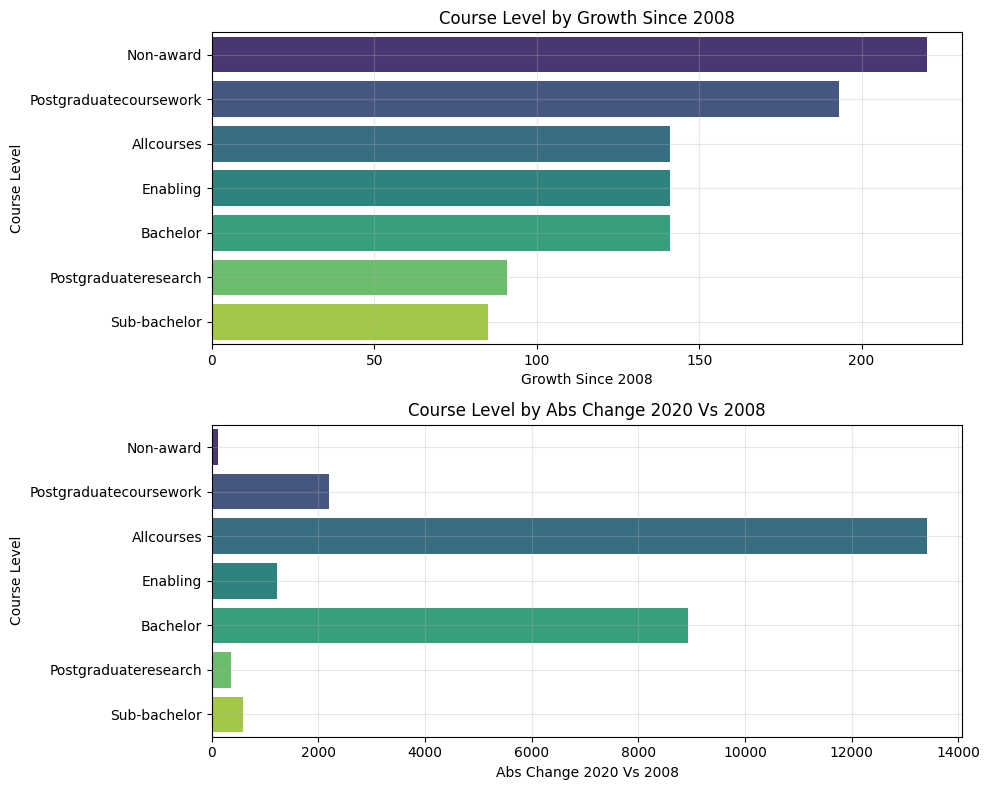

In [65]:
metrics = [c for c in ["growth_since_2008", "abs_change_2020_vs_2008"] if c in d.columns]
if metrics:
    num_metrics = len(metrics)
    plt.figure(figsize=(10, 4 * num_metrics))
    for i, metric in enumerate(metrics, 1):
        plt.subplot(num_metrics, 1, i)
        sns.barplot(data=d, y="course_level", x=metric, palette="viridis")
        plt.title(f"Course Level by {metric.replace('_', ' ').title()}")
        plt.xlabel(metric.replace('_', ' ').title())
        plt.ylabel("Course Level")
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [66]:
#statistical summary of numeric columns
numeric_cols = d.select_dtypes(include=[np.number]).columns
if not numeric_cols.empty:
    summary = d[numeric_cols].describe().T
    summary["missing"] = d[numeric_cols].isna().sum()
    display(summary)

,count,mean,std,min,25%,50%,75%,max,missing
2008,7.0,2711.428571,3688.412480,50.000000,539.500000,871.000000,3745.000000,9490.00000,0
2020,7.0,6542.000000,8908.672516,160.000000,1009.500000,2097.000000,9310.500000,22897.00000,0
growth_since_2008,7.0,144.571429,49.145556,85.000000,116.000000,141.000000,167.000000,220.00000,0
annual_avg_growth_since_2008,7.0,7.591934,1.801774,5.252623,6.570163,7.596552,8.487899,10.17824,0
abs_change_2020_vs_2008,7.0,3830.571429,5223.781448,110.000000,470.000000,1226.000000,5565.500000,13407.00000,0


###Progress signals

System-wide growth: All courses +141% from 2008→2020 (CAGR ≈ 7.6%), absolute +13,407 enrolments.

Scale is driven by Bachelor: +8,939 (≈ 66.7% of total growth) at the same CAGR as overall (~7.6%).

Postgrad coursework is the second engine: +2,192 (16.3% of total), CAGR ~9.36%.

Enabling programs grew at the same relative rate as Bachelor (+141%, CAGR ~7.6%) albeit from a smaller base (+1,226).

Pressure points (from this snapshot)

Research pipeline is weak: Postgrad research grew +91% (CAGR ~5.55%) for only +358 seats (2.7% of total growth).

Sub-bachelor is the slowest relative mover: +85% (CAGR ~5.25%), +582 (4.3% of total growth).

Non-award has the fastest relative rate (+220%, CAGR ~10.18%) but trivial scale (+110, 0.8% of total), so it doesn’t shift system totals.

What this implies (within the limits of the table)

Expansion happened, but most of the uplift sits in Bachelor and coursework Masters. If the goal includes cultivating future Indigenous academics, the research track is the clear bottleneck in both rate and absolute numbers.

Pathway programs (Enabling) kept pace percentage-wise, but their absolute contribution to growth is modest, so they aren’t yet scaling the pipeline proportionally.

For category comparisons, avoid plotting the aggregate “All courses” alongside categories when interpreting contributions; it dominates the absolute-change axis.

### Part 3: Questionnaire on Integrating Indigenous Perspectives into DS Education

Thanks for the opportunity to participate in this questionnaire. 